
# Home Credit Default Risk


This notebook covers:
- **EDA** with a large number of visualizations (distributions, correlations, omissions, comparison by target).
- **Data cleaning**, the specifics of anomalies (for example, `DAYS_EMPLOYED == 365243`).
- **Comparison of encoders** of categorical features: `OneHot`, `Ordinary`, `Target`, `CatBoostEncoder'.
- **Feature selection**: `SelectKBest', `Permutation Importance', `SHAP-based` (with aggregation to "raw" features).
- **Interpreted models**: `Logistic Regression`, `Decision Tree`, `LightGBM` (in interpretation-oriented configurations).
- **Interpretation**: importance, coefficients, tree rules, SHAP summary + dependence, PDP.

> **Resource Note:** Calculations can be expensive on a full dataset. Sampling options are provided below to quickly get representative results.


**Abstract (Аннотация).**  
The paper presents a reproducible credit scoring pipeline based on the Home Credit Default Risk dataset: EDA, purification, categorical feature encoding, feature selection, and training of interpreted models (Logistic Regression, Decision Tree, LightGBM) with detailed interpretation (Permutation Importance, SHAP, PDP). We describe the methodology, leak prevention, validation settings, and criteria for selecting final approaches.

**Contents**
1. Introduction and methodology
2. Description of the data and the target variable
3. EDA and key observations
4. Preprocessing and encoding of features
5. Feature selection (SelectKBest, Permutation, SHAP)
6. Models and validation
7. Interpretation of results
8. Conclusions, limitations and further work


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Installing dependencies



In [2]:

%pip install -q pandas numpy scikit-learn lightgbm xgboost catboost category-encoders shap matplotlib seaborn plotly boruta



## Imports and general settings


In [3]:

import os
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold, train_test_split, cross_validate
from sklearn.metrics import (
    roc_auc_score, average_precision_score, log_loss, accuracy_score,
    roc_curve, auc, precision_recall_curve
)
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.inspection import permutation_importance, PartialDependenceDisplay

# Optional libraries
HAS_CE = False
try:
    import category_encoders as ce
    HAS_CE = True
except Exception:
    pass

HAS_LGBM = False
try:
    from lightgbm import LGBMClassifier
    HAS_LGBM = True
except Exception:
    pass

HAS_XGB = False
try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except Exception:
    pass

HAS_CATBOOST = False
try:
    from catboost import CatBoostClassifier
    HAS_CATBOOST = True
except Exception:
    pass

HAS_SHAP = False
try:
    import shap
    HAS_SHAP = True
except Exception:
    pass

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Sampling parameters for heavy calculations
N_SAMPLE_CV = 120_000         # for comparing encoders
N_SAMPLE_PI_VALID = 15_000    # for permutation importance
N_SAMPLE_SHAP = 30_000        # for SHAPE__K_
FEATURES = 50                 # how many features to leave during selection

# Visualization options
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True
sns.set(style="whitegrid")



## Data uploading



In [4]:

train_path="/content/drive/MyDrive/application_train.csv"


df = pd.read_csv(train_path)
print('Size application_train:', df.shape)
display(df.head())


Size application_train: (307511, 122)


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0



## Target variable and class imbalance


TARGET
0    282686
1     24825
Name: count, dtype: int64

Class 1 share: 0.0807


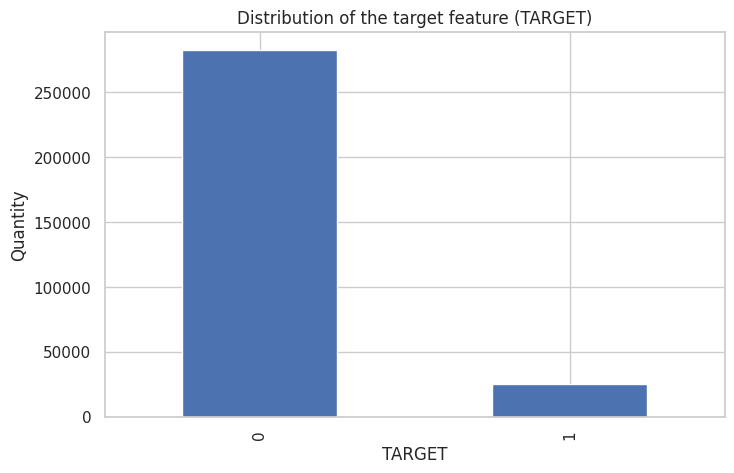

In [5]:

assert 'TARGET' in df.columns, "The TARGET variable is missing from the dataset"
print(df['TARGET'].value_counts())
print('\nClass 1 share:', df['TARGET'].mean().round(4))

# Бар-чарт по целевой
ax = df['TARGET'].value_counts().sort_index().plot(kind='bar')
ax.set_title('Distribution of the target feature (TARGET)')
ax.set_xlabel('TARGET')
ax.set_ylabel('Quantity')
plt.show()



**Interpretation (Fig. 1. The distribution Of The `TARGET').**  

There is a pronounced class imbalance (the proportion of `TARGET=1` is significantly lower than `TARGET=0`). This affects the choice of metrics and training.:
- We use **ROC‑AUC** and **PR‑AUC** instead of Accuracy alone.  
- Stratified breakdown of validation is mandatory; for threshold classification, we adjust the threshold based on ** the cost of errors** (false approvals/bounce rate).
- In models, it is acceptable to use `class_weight='balanced` (LR) or `scale_pos_weight` (boosting), if necessary.



## Missing Values
Let’s calculate the share of missing values and look at the top features by number of missing values.


,missing_pct,missing_cnt
COMMONAREA_AVG,0.698723,214865
COMMONAREA_MODE,0.698723,214865
COMMONAREA_MEDI,0.698723,214865
NONLIVINGAPARTMENTS_MEDI,0.694330,213514
NONLIVINGAPARTMENTS_MODE,0.694330,213514
NONLIVINGAPARTMENTS_AVG,0.694330,213514
FONDKAPREMONT_MODE,0.683862,210295
LIVINGAPARTMENTS_AVG,0.683550,210199
LIVINGAPARTMENTS_MEDI,0.683550,210199
LIVINGAPARTMENTS_MODE,0.683550,210199


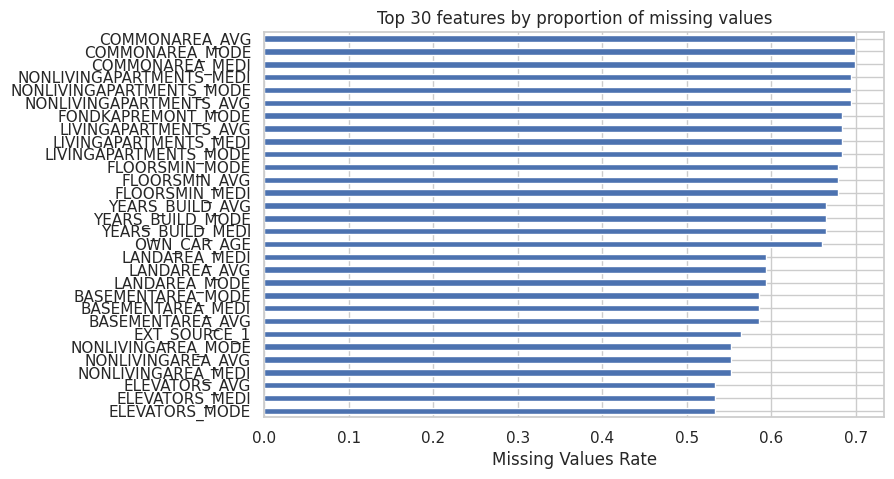

In [6]:

missing = df.isna().mean().sort_values(ascending=False).to_frame('missing_pct')
missing['missing_cnt'] = df.isna().sum().sort_values(ascending=False).values
display(missing.head(20))

top_missing = missing.head(30).iloc[::-1]  # invert it for a horizontal bar chart
ax = top_missing['missing_pct'].plot(kind='barh')
ax.set_xlabel('Missing Values Rate')
ax.set_title('Top 30 features by proportion of missing values')
plt.show()



**Interpretation (Fig. 2. Top-30 in terms of the share of omissions).**  
The upper signs on the chart require a separate imputation strategy. Credit scoring omissions are rarely completely random (MCAR); more often they are MAR/MNAR and informative in themselves. Practically, this means:
- For categorical features, we add a separate category/indicator **`missing`**.  
- For numerical values, we use **median impact** and, if necessary, the "value was skipped" indicator.  
- We process technical markers separately (for example, `DAYS_EMPLOYED == 365243` as `NaN`).  
This scheme reduces bias and preserves information related to the "fact of missing data."



## Basic cleaning and primary feature generation
- In `DAYS_EMPLOYED`, the value `365243` is the technical marker "no data", we will replace it with `NaN`.
- Let's construct the age in years from `DAYS_BIRTH` (if any).
- () A few simple sum/income relations.



**Explanation of the preprocessing.**  
- Replace `DAYS_EMPLOYED == 365243` with `NaN', since this is the "no seniority" code in the original upload.  
- Derived features `AGE_YEARS`, `CREDIT_INCOME_PCT', `ANNUITY_INCOME_PCT`, `CREDIT_ANNUITY_RATIO' introduce economic meaning and improve the expressivity of the model.  
- All calculations are performed **inside the pipeline** on training folds to eliminate leakage.

In [7]:

df_clean = df.copy()

# Specifics of Home Credit: anomaly 365243 in DAYS_EMPLOYED
if 'DAYS_EMPLOYED' in df_clean.columns:
    df_clean['DAYS_EMPLOYED'] = df_clean['DAYS_EMPLOYED'].replace(365243, np.nan)

# Age
if 'DAYS_BIRTH' in df_clean.columns:
    df_clean['AGE_YEARS'] = - df_clean['DAYS_BIRTH'] / 365.25

# Simple relationships (if there are columns)
def safe_ratio(a, b):
    return a / (b.replace(0, np.nan)) if hasattr(b, 'replace') else a / b

if set(['AMT_CREDIT','AMT_INCOME_TOTAL']).issubset(df_clean.columns):
    df_clean['CREDIT_INCOME_PCT'] = df_clean['AMT_CREDIT'] / (df_clean['AMT_INCOME_TOTAL'].replace(0, np.nan))
if set(['AMT_ANNUITY','AMT_INCOME_TOTAL']).issubset(df_clean.columns):
    df_clean['ANNUITY_INCOME_PCT'] = df_clean['AMT_ANNUITY'] / (df_clean['AMT_INCOME_TOTAL'].replace(0, np.nan))
if set(['AMT_CREDIT','AMT_ANNUITY']).issubset(df_clean.columns):
    df_clean['CREDIT_ANNUITY_RATIO'] = df_clean['AMT_CREDIT'] / (df_clean['AMT_ANNUITY'].replace(0, np.nan))

print('Size after basic cleaning/FE:', df_clean.shape)


Size after basic cleaning/FE: (307511, 126)



## Automatic feature type detection
Integers with low cardinality are treated as categorical features.


In [8]:

def detect_feature_types(df_in: pd.DataFrame, target: str, int_as_cat_max_uniques: int = 20):
    numeric, categorical = [], []
    for col in df_in.columns:
        if col == target:
            continue
        s = df_in[col]
        if pd.api.types.is_numeric_dtype(s):
            if pd.api.types.is_integer_dtype(s) and s.nunique(dropna=True) <= int_as_cat_max_uniques:
                categorical.append(col)
            else:
                numeric.append(col)
        else:
            categorical.append(col)
    return numeric, categorical

numeric_cols, categorical_cols = detect_feature_types(df_clean, 'TARGET', int_as_cat_max_uniques=20)
print('Numerical:', len(numeric_cols), '| Categorical:', len(categorical_cols))


Numerical: 74 | Categorical: 51



## Numerical signs: correlation with `TARGET' (Spearman)
Let's show the top 20 by absolute correlation.


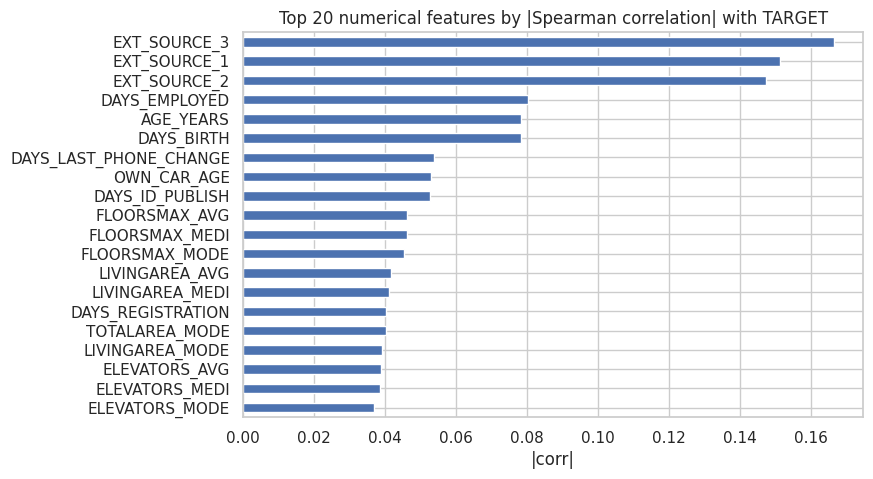

In [9]:

num_for_corr = [c for c in numeric_cols if c != 'TARGET']
corr_s = df_clean[num_for_corr + ['TARGET']].corr(method='spearman')['TARGET'].drop('TARGET').abs().sort_values(ascending=False)
top20 = corr_s.head(20).iloc[::-1]

ax = top20.plot(kind='barh')
ax.set_title('Top 20 numerical features by |Spearman correlation| with TARGET')
ax.set_xlabel('|corr|')
plt.show()



**Interpretation (Fig. 3. Top-20 |Spearman corr|).**  
Spearman's correlation indicates monotonous connections between signs and risk. In credit scoring tasks, strong anti‑correlators are expected — external scoring sources `EXT_SOURCE_*` and age (`DAYS_BIRTH`), and load factors (loan amount, annuity, credit/income ratio) show a positive relationship with risk. It should be remembered that correlation ** is not** equal to causality, and multicollinearity can "blur" the contribution of individual features.



## Categorical features: target share by category
For features with cardinality < 10, we visualize the average `TARGET` by category.

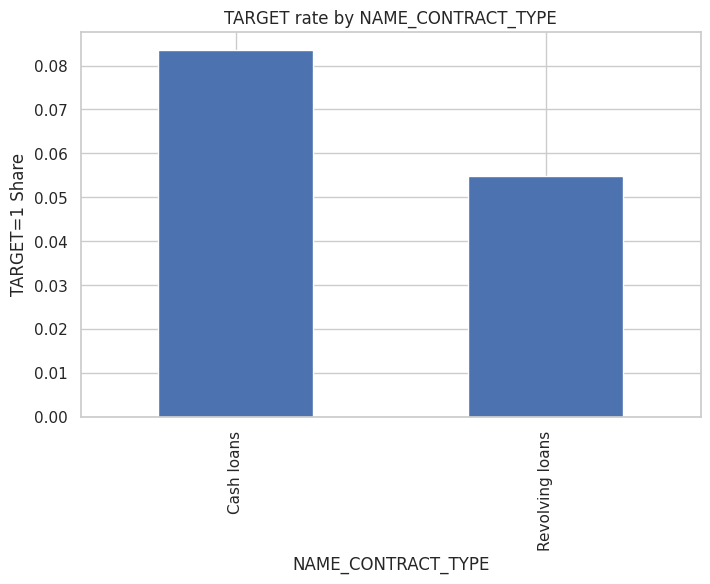

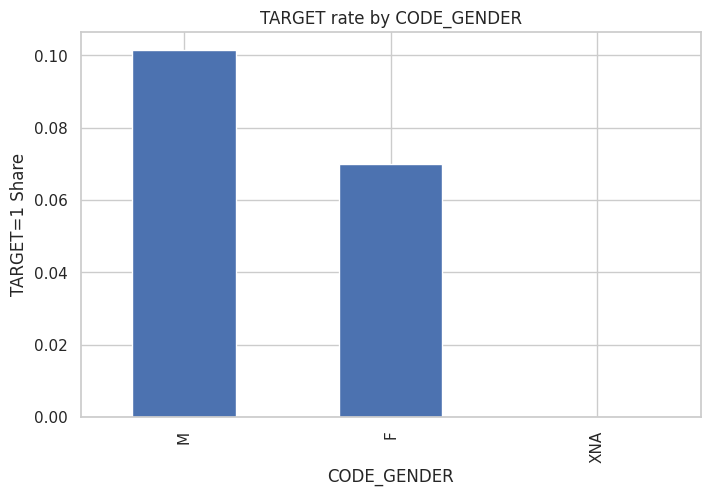

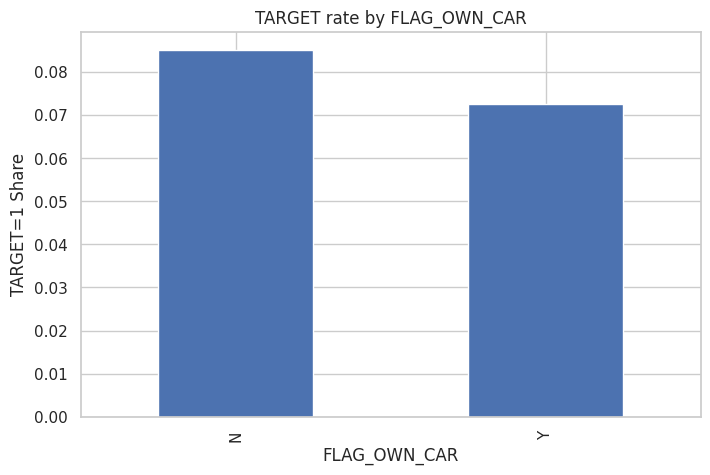

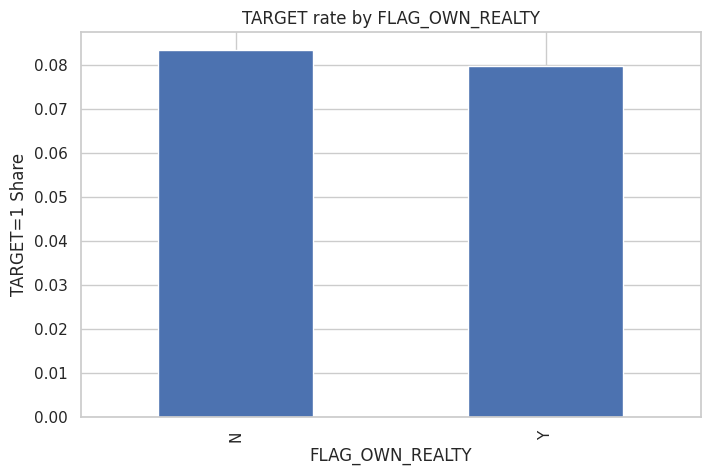

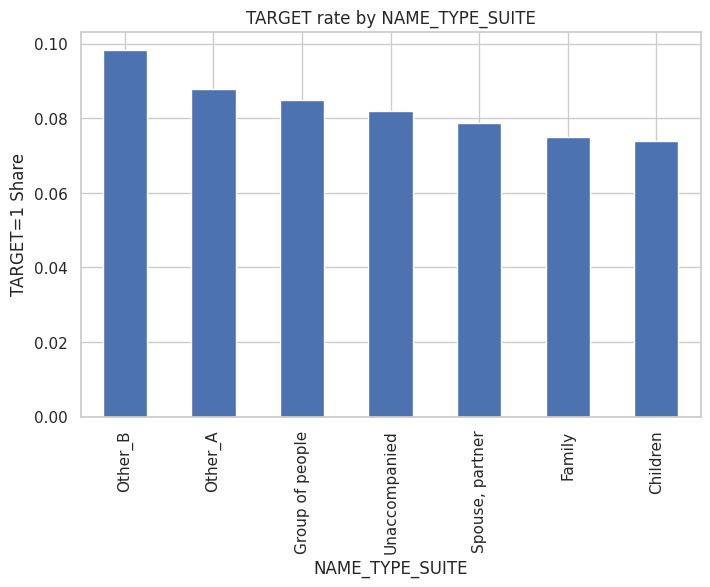

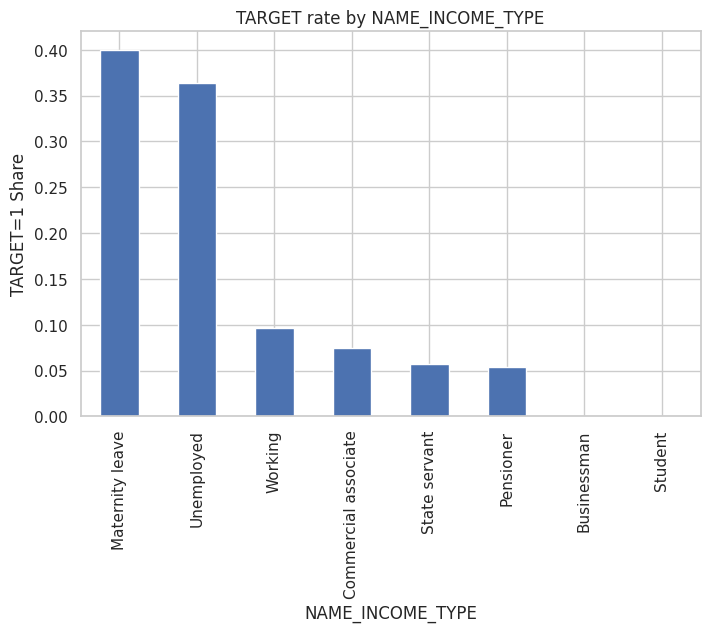

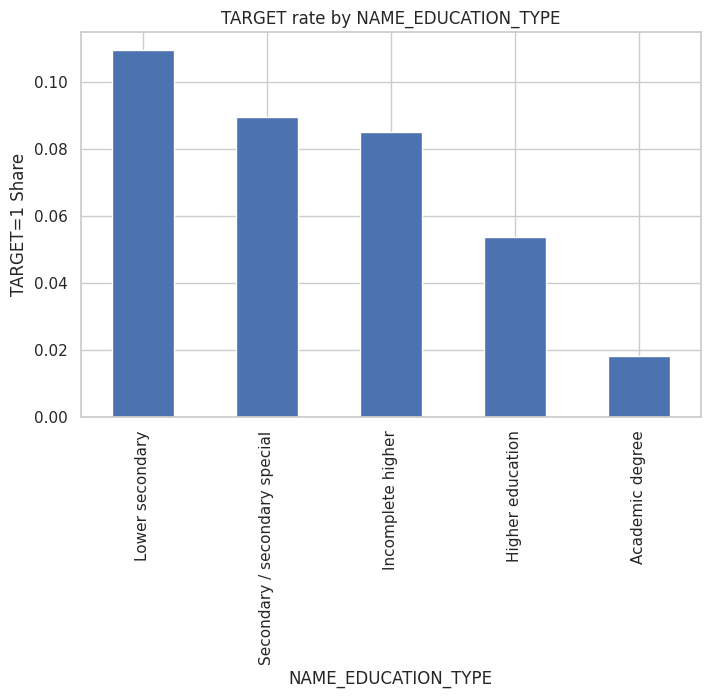

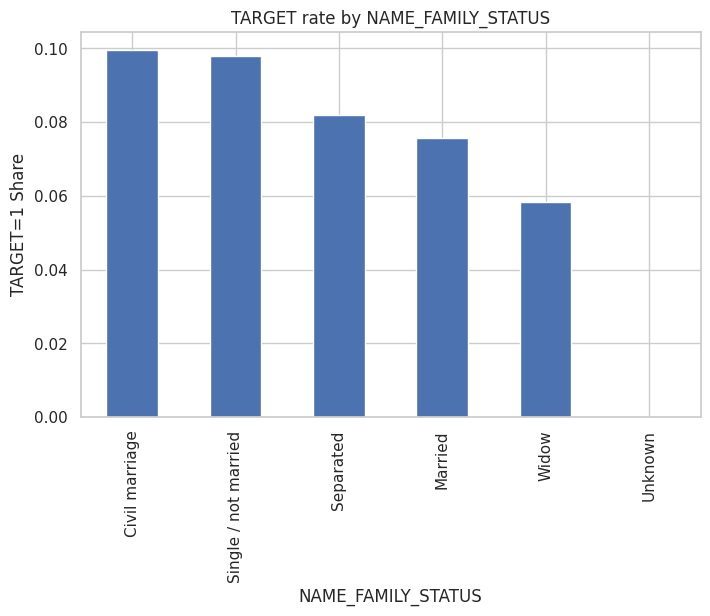

In [10]:

low_card = [c for c in categorical_cols if df_clean[c].nunique(dropna=False) <= 10]
for c in low_card[:8]:
    rates = df_clean.groupby(c)['TARGET'].mean().sort_values(ascending=False)
    ax = rates.plot(kind='bar')
    ax.set_ylabel('TARGET=1 Share')
    ax.set_title(f'TARGET rate by {c}')
    plt.show()



**Interpretation (Fig. 4. TARGET‑rate for categorical features).**  
The bar charts show the default percentage by category. The observations are typical: less stable socio‑economic statuses (temporary employment, lack of property) correlate with increased risk; more stable statuses correlate with reduced risk. For high‑margin features, it makes sense to switch to target coding in order to avoid an explosion of dimensionality.


## Heat map of correlations (top 25 numerical features according to |corr|)


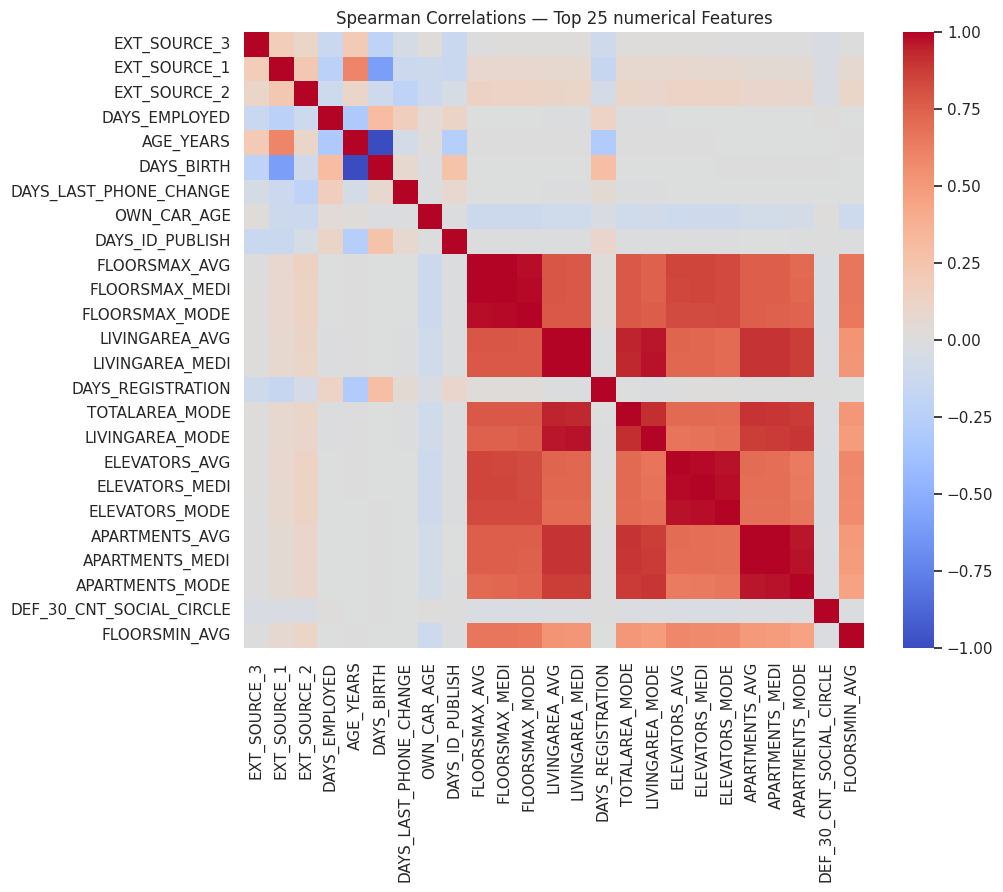

In [11]:

top25_cols = corr_s.head(25).index.tolist()
corr_mat = df_clean[top25_cols].corr(method='spearman')
plt.figure(figsize=(10, 8))
sns.heatmap(corr_mat, cmap='coolwarm', center=0)
plt.title('Spearman Correlations — Top 25 numerical Features')
plt.show()



**Interpretation (Fig. 5. Spearman's heat map).**  
Groups of closely related features (clusters) signal multicollinearity. This is important when choosing models: linear models can "suffer" from unstable coefficients, whereas trees and boosting are more stable. For a linear model, more rigorous feature selection or regularization is appropriate.



## Preprocessor construction and auxiliary functions


In [13]:

from typing import List, Dict, Tuple
from sklearn.base import BaseEstimator

def make_preprocessor(encoder_name: str,
                      numeric_features: List[str],
                      categorical_features: List[str],
                      scale_numeric: bool) -> ColumnTransformer:
    num_steps = [('imputer', SimpleImputer(strategy='median'))]
    if scale_numeric:
        num_steps.append(('scaler', StandardScaler()))
    num_pipe = Pipeline(steps=num_steps)

    if encoder_name.lower() == 'onehot':
        cat_pipe = Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
        ])
    elif encoder_name.lower() == 'ordinal':
        cat_pipe = Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('ord', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
        ])
    elif encoder_name.lower() in ('target', 'catboost'):
        if not HAS_CE:
            raise RuntimeError("The category-encoders package is required. Install and restart.")
        enc = ce.TargetEncoder() if encoder_name.lower() == 'target' else ce.CatBoostEncoder()
        cat_pipe = Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('tgt', enc)
        ])
    else:
        raise ValueError(f'Unknown encoder: {encoder_name}')

    pre = ColumnTransformer(
        transformers=[
            ('num', num_pipe, numeric_features),
            ('cat', cat_pipe, categorical_features)
        ],
        remainder='drop',
        verbose_feature_names_out=True
    )
    return pre

def get_feature_names_after_preprocess(fitted_pre: ColumnTransformer) -> np.ndarray:
    names = []
    for name, trans, cols in fitted_pre.transformers_:
        if name == 'num':
            names.extend(list(cols))
        elif name == 'cat':
            cat_cols = list(cols)
            last_step_name, last_step = trans.steps[-1]
            if hasattr(last_step, 'get_feature_names_out'):
                try:
                    out = last_step.get_feature_names_out(cat_cols)
                    names.extend(list(out))
                except Exception:
                    names.extend([f'{c}__enc' for c in cat_cols])
            else:
                suffix = '__ord' if last_step_name == 'ord' else '__enc'
                names.extend([f'{c}{suffix}' for c in cat_cols])
    return np.array(names)

def map_transformed_to_raw(fitted_pre: ColumnTransformer) -> Dict[str, str]:
    mapping = {}
    for name, trans, cols in fitted_pre.transformers_:
        if name == 'num':
            for c in cols:
                mapping[c] = c
        elif name == 'cat':
            cat_cols = list(cols)
            last_step_name, last_step = trans.steps[-1]
            if hasattr(last_step, 'get_feature_names_out'):
                out = last_step.get_feature_names_out(cat_cols)
                for tname in out:
                    raw = str(tname).split('_', 1)[0]
                    mapping[str(tname)] = raw
            else:
                suffix = '__ord' if last_step_name == 'ord' else '__enc'
                for c in cat_cols:
                    mapping[f'{c}{suffix}'] = c
    return mapping


## Comparison of encoders (OneHot / Ordinary / Target / CatBoostEncoder) × models (LogReg / LightGBM)
We estimate the following metrics by 5‑fold CV per sample (120k lines by default): ROC AUC, AP, LogLoss, Accuracy.

,encoder,model,roc_auc,ap,logloss,accuracy
0,target,lgbm,0.759461,0.239964,0.245428,0.919983
1,ordinal,lgbm,0.758915,0.240913,0.245470,0.919842
2,onehot,lgbm,0.758883,0.240384,0.245547,0.919933
3,catboost,lgbm,0.758645,0.240396,0.245609,0.919883
4,onehot,logreg,0.744245,0.218215,0.249999,0.919408
5,ordinal,logreg,0.743412,0.216473,0.250207,0.919367
6,target,logreg,0.740436,0.213963,0.251086,0.919667
7,catboost,logreg,0.739854,0.213201,0.251282,0.919558


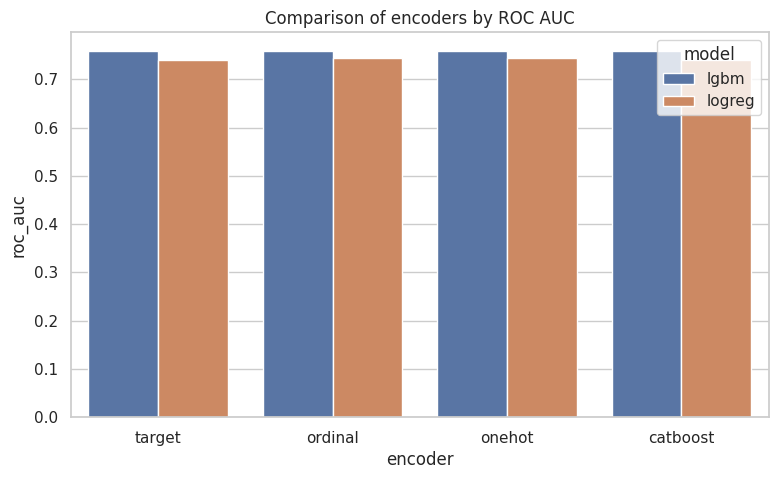

In [14]:

from dataclasses import dataclass

@dataclass
class EvalResult:
    encoder: str
    model: str
    roc_auc: float
    ap: float
    logloss: float
    accuracy: float

def evaluate_encoder_with_model(X: pd.DataFrame, y: pd.Series,
                                encoder_name: str, model_name: str,
                                numeric_features: List[str], categorical_features: List[str],
                                cv_splits: int = 5) -> EvalResult:
    scale_numeric = (model_name.lower() == 'logreg')
    pre = make_preprocessor(encoder_name, numeric_features, categorical_features, scale_numeric)
    if model_name.lower() == 'logreg':
        model = LogisticRegression(max_iter=1000, n_jobs=None)
    elif model_name.lower() == 'lgbm':
        assert HAS_LGBM, "LightGBM is not installed"
        model = LGBMClassifier(
            n_estimators=400, learning_rate=0.05, max_depth=5, num_leaves=31,
            min_child_samples=50, subsample=0.8, colsample_bytree=0.8,
            random_state=RANDOM_STATE, importance_type='gain'
        )
    else:
        raise ValueError('logreg and lgbm are supported')
    pipe = Pipeline([('pre', pre), ('model', model)])

    scoring = {'roc_auc': 'roc_auc', 'ap': 'average_precision',
               'logloss': 'neg_log_loss', 'accuracy': 'accuracy'}
    cv = StratifiedKFold(n_splits=cv_splits, shuffle=True, random_state=RANDOM_STATE)
    res = cross_validate(pipe, X, y, scoring=scoring, cv=cv, n_jobs=-1, error_score='raise')

    return EvalResult(
        encoder=encoder_name, model=model_name,
        roc_auc=float(np.mean(res['test_roc_auc'])),
        ap=float(np.mean(res['test_ap'])),
        logloss=float(-np.mean(res['test_logloss'])),
        accuracy=float(np.mean(res['test_accuracy']))
    )

# Sample for CV
df_cv = df_clean.sample(min(N_SAMPLE_CV, len(df_clean)), random_state=RANDOM_STATE)
X_cv = df_cv.drop(columns=['TARGET'])
y_cv = df_cv['TARGET']

encoders = ['onehot', 'ordinal']
if HAS_CE:
    encoders += ['target', 'catboost']

models = ['logreg'] + (['lgbm'] if HAS_LGBM else [])

results = []
for m in models:
    for e in encoders:
        try:
            r = evaluate_encoder_with_model(X_cv, y_cv, e, m, numeric_cols, categorical_cols, cv_splits=5)
            results.append(r.__dict__)
        except Exception as ex:
            print(f'[WARN] {m} + {e}: {ex}')
            results.append({'encoder': e, 'model': m, 'roc_auc': np.nan, 'ap': np.nan, 'logloss': np.nan, 'accuracy': np.nan})

res_df = pd.DataFrame(results).sort_values(['model','roc_auc'], ascending=[True, False]).reset_index(drop=True)
display(res_df)

# Visualisation of ROC AUC
plt.figure(figsize=(9,5))
ax = sns.barplot(data=res_df, x='encoder', y='roc_auc', hue='model')
ax.set_title('Comparison of encoders by ROC AUC')
plt.show()


**Interpretation (Fig. 6. Comparison of encoders by ROC‑AUC).**  
- For **Logistic Regression**, **One‑Hot Encoding** is most often preferred, since it allows you to interpret the contribution of each category and avoids artificial order.  
- For **trees/boosting**, **Ordinary** is acceptable; with high cardinality, **Target/CatBoost Encoders** benefit.
- Important: target encoding is applied **strictly within cross‑validation** (as part of the `Pipeline`), otherwise there is a leakage of the target and an overestimation of metrics.
The final choice of the encoder is fixed based on a combination of quality, interpretability and stability.



## SelectKBest (mutual_info) + model (default is LightGBM)


In [17]:
def select_kbest_pipeline(X: pd.DataFrame, y: pd.Series,
                          encoder_name: str, numeric_features: List[str],
                          categorical_features: List[str], k: int,
                          model_name: str = 'lgbm') -> tuple:
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
    )
    scale_numeric = (model_name.lower() == 'logreg')
    pre = make_preprocessor(encoder_name, numeric_features, categorical_features, scale_numeric)
    selector = SelectKBest(mutual_info_classif, k=k)

    if model_name.lower() == 'logreg':
        model = LogisticRegression(max_iter=1000)
    else:
        assert HAS_LGBM, "LightGBM не установлен"
        model = LGBMClassifier(
            n_estimators=400, learning_rate=0.05, max_depth=5, num_leaves=31,
            min_child_samples=50, subsample=0.8, colsample_bytree=0.8,
            random_state=RANDOM_STATE, importance_type='gain'
        )
    pipe = Pipeline([('pre', pre), ('kbest', selector), ('model', model)])
    pipe.fit(X_train, y_train)

    proba = pipe.predict_proba(X_test)[:,1]
    pred = (proba >= 0.5).astype(int)
    metrics = {
        'roc_auc': roc_auc_score(y_test, proba),
        'ap': average_precision_score(y_test, proba),
        'logloss': log_loss(y_test, proba),
        'accuracy': accuracy_score(y_test, pred)
    }
    return pipe, metrics

pipe_kbest, kbest_metrics = select_kbest_pipeline(
    X_cv.drop(columns=[]), y_cv,
    encoder_name='onehot', numeric_features=numeric_cols, categorical_features=categorical_cols,
    k=min(FEATURES, len(numeric_cols) + len(categorical_cols)), model_name='lgbm' if HAS_LGBM else 'logreg'
)
print('SelectKBest metrics:', kbest_metrics)

[LightGBM] [Info] Number of positive: 7716, number of negative: 88284
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.055683 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 793
[LightGBM] [Info] Number of data points in the train set: 96000, number of used features: 42
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080375 -> initscore=-2.437263
[LightGBM] [Info] Start training from score -2.437263
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain:

**Interpretation.**  
'SelectKBest' (mutual information) acts as a fast filter: it selects features with the most mutual information with the target. It does not take into account the interaction between the signs, so it is convenient to use it as **primary screening**, and then confirm the significance with permutations or shaps.



## Permutation Importance (at the level of "raw" attributes)
Let's build a pipeline `Preprocessor(OneHot) → LightGBM` and evaluate the importance of permutations on validation.

[LightGBM] [Info] Number of positive: 19860, number of negative: 226148
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.357094 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 12771
[LightGBM] [Info] Number of data points in the train set: 246008, number of used features: 270
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080729 -> initscore=-2.432482
[LightGBM] [Info] Start training from score -2.432482
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best

,feature,importance_mean,importance_std
0,EXT_SOURCE_3,0.055584,0.003205
1,EXT_SOURCE_2,0.040863,0.003054
2,CREDIT_ANNUITY_RATIO,0.020358,0.001280
3,EXT_SOURCE_1,0.016108,0.001865
4,AMT_GOODS_PRICE,0.015318,0.002051
5,AMT_CREDIT,0.005280,0.001340
6,AMT_ANNUITY,0.003851,0.001355
7,CODE_GENDER,0.003476,0.001458
8,NAME_EDUCATION_TYPE,0.003163,0.000985
9,NAME_CONTRACT_TYPE,0.002613,0.001536


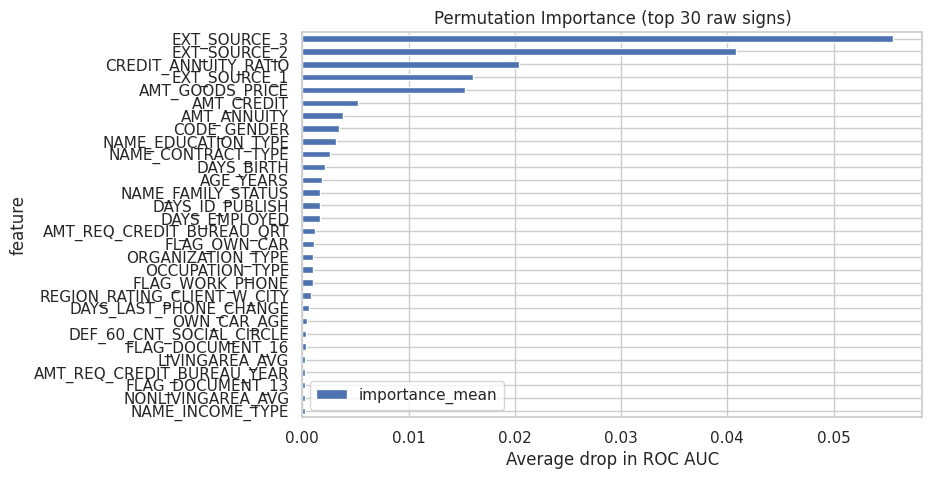

In [19]:
def build_pipe_for_raw_features(encoder_name: str, raw_numeric: List[str], raw_categorical: List[str], model_name: str):
    scale_numeric = (model_name.lower() == 'logreg')
    pre = make_preprocessor(encoder_name, raw_numeric, raw_categorical, scale_numeric)
    if model_name.lower() == 'logreg':
        model = LogisticRegression(max_iter=1000)
    else:
        assert HAS_LGBM, "LightGBM is not installed"
        model = LGBMClassifier(
            n_estimators=500, learning_rate=0.05, max_depth=5, num_leaves=31,
            min_child_samples=50, subsample=0.8, colsample_bytree=0.8,
            random_state=RANDOM_STATE, importance_type='gain'
        )
    return Pipeline([('pre', pre), ('model', model)])

# Holdout для PI
X_train_pi, X_valid_pi, y_train_pi, y_valid_pi = train_test_split(
    df_clean.drop(columns=['TARGET']), df_clean['TARGET'],
    test_size=0.2, stratify=df_clean['TARGET'], random_state=RANDOM_STATE
)
# To speed up, reduce the validation
val_idx = np.random.RandomState(RANDOM_STATE).choice(len(X_valid_pi), size=min(N_SAMPLE_PI_VALID, len(X_valid_pi)), replace=False)
X_valid_pi_s = X_valid_pi.iloc[val_idx]
y_valid_pi_s = y_valid_pi.iloc[val_idx]

pipe_pi = build_pipe_for_raw_features('onehot', numeric_cols, categorical_cols, model_name='lgbm' if HAS_LGBM else 'logreg')
pipe_pi.fit(X_train_pi, y_train_pi)

r = permutation_importance(pipe_pi, X_valid_pi_s, y_valid_pi_s, n_repeats=10, random_state=RANDOM_STATE, scoring='roc_auc')
pi_df = pd.DataFrame({
    'feature': X_valid_pi_s.columns,
    'importance_mean': r.importances_mean,
    'importance_std': r.importances_std
}).sort_values('importance_mean', ascending=False).reset_index(drop=True)
display(pi_df.head(30))

top_raw_perm = pi_df.head(FEATURES)['feature'].tolist()

ax = pi_df.head(30).iloc[::-1].plot(kind='barh', x='feature', y='importance_mean')
ax.set_title('Permutation Importance (top 30 raw signs)')
ax.set_xlabel('Average drop in ROC AUC')
plt.show()


**Interpretation (Fig. 7. Permutation importance according to "raw" features).**  
Permutations measure the drop of a metric when a column is randomly rearranged. The advantage is that they relate to the **source** features before encoding, which simplifies business interpretation. `EXT_SOURCE_*`, `DAYS_BIRTH`, debt load indexes and derivative relationships are consistently appearing among the top features.


## SHAP‑based selection and interpretation ()
We will use `LightGBM` + `TreeExplainer'. For big data, we sample validation.

[LightGBM] [Info] Number of positive: 19860, number of negative: 226148
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.506581 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 12771
[LightGBM] [Info] Number of data points in the train set: 246008, number of used features: 270
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080729 -> initscore=-2.432482
[LightGBM] [Info] Start training from score -2.432482
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best

,raw,abs_shap
42,EXT_SOURCE_3,0.352066
41,EXT_SOURCE_2,0.321570
63,NAME,0.263264
3,AMT_GOODS_PRICE,0.183763
43,FLAG,0.182867
24,CREDIT_ANNUITY_RATIO,0.176984
40,EXT_SOURCE_1,0.162519
20,CODE,0.115200
27,DAYS_EMPLOYED,0.105396
1,AMT_ANNUITY,0.096182


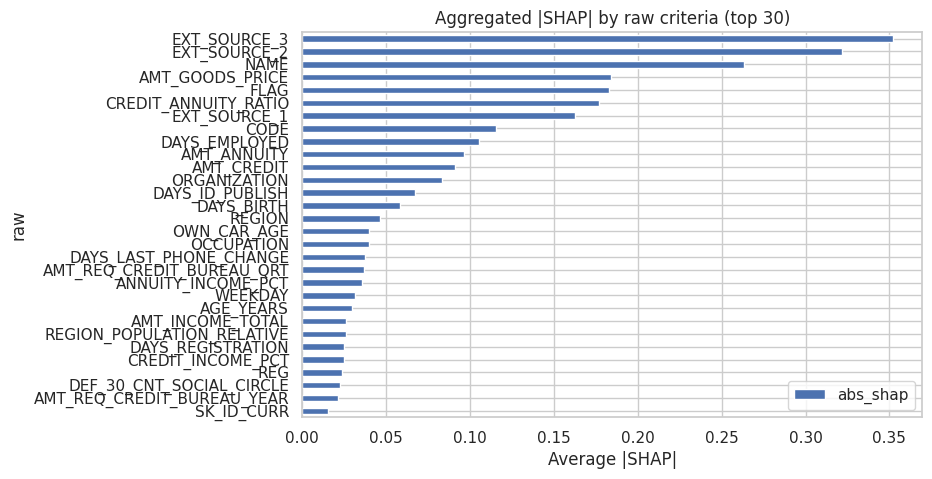

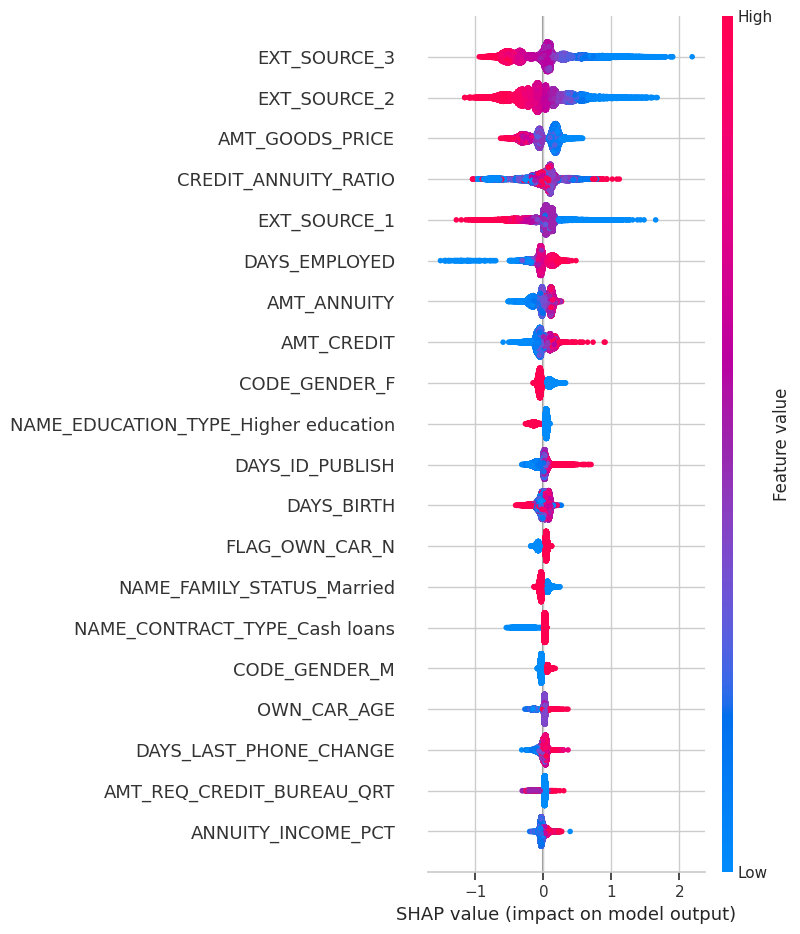

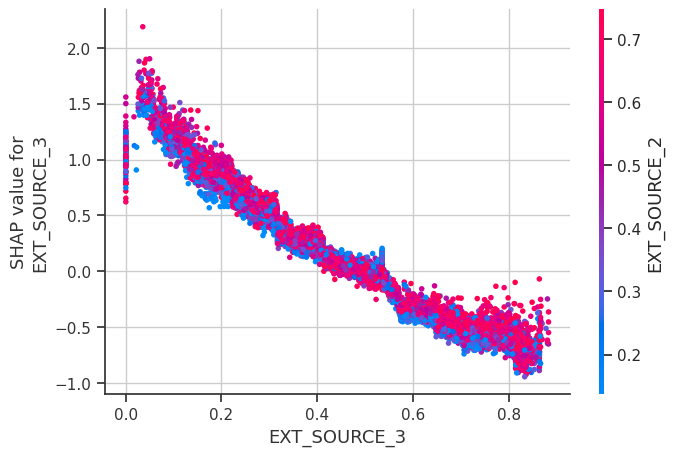

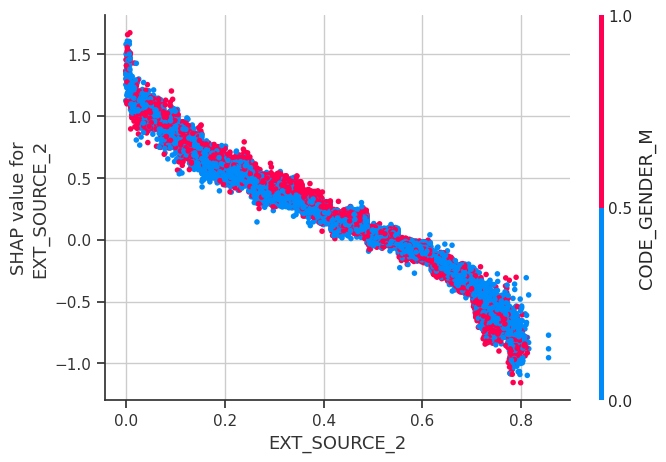

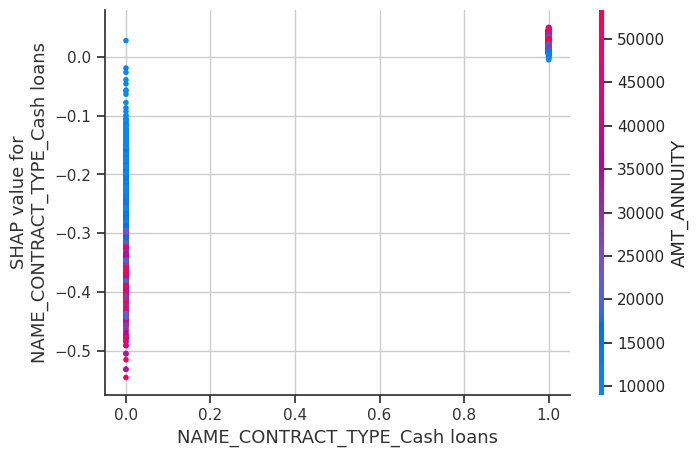

In [21]:

top_raw_shap = []
if HAS_SHAP and HAS_LGBM:
    # Train pipeline on train subset
    X_train_s, X_valid_s, y_train_s, y_valid_s = train_test_split(
        df_clean.drop(columns=['TARGET']), df_clean['TARGET'],
        test_size=0.2, stratify=df_clean['TARGET'], random_state=RANDOM_STATE
    )
    # let's limit valid for shap
    valid_idx = np.random.RandomState(RANDOM_STATE).choice(len(X_valid_s), size=min(N_SAMPLE_SHAP, len(X_valid_s)), replace=False)
    Xv = X_valid_s.iloc[valid_idx]
    yv = y_valid_s.iloc[valid_idx]

    pre = make_preprocessor('onehot', numeric_cols, categorical_cols, scale_numeric=False)
    model = LGBMClassifier(
        n_estimators=700, learning_rate=0.05, max_depth=5, num_leaves=31,
        min_child_samples=50, subsample=0.8, colsample_bytree=0.8,
        random_state=RANDOM_STATE, importance_type='gain'
    )
    pipe_shap = Pipeline([('pre', pre), ('model', model)])
    pipe_shap.fit(X_train_s, y_train_s)

    Xv_trans = pipe_shap.named_steps['pre'].transform(Xv)
    model_f = pipe_shap.named_steps['model']
    explainer = shap.TreeExplainer(model_f, feature_perturbation="tree_path_dependent")
    sv = explainer.shap_values(Xv_trans)
    if isinstance(sv, list):
        sv = sv[1]  # for a binary task
    feat_names_trans = get_feature_names_after_preprocess(pipe_shap.named_steps['pre'])
    to_raw = map_transformed_to_raw(pipe_shap.named_steps['pre'])
    df_imp = pd.DataFrame({
        'transformed': feat_names_trans,
        'raw': [to_raw.get(n, n) for n in feat_names_trans],
        'abs_shap': np.abs(sv).mean(axis=0)
    })
    agg = df_imp.groupby('raw', as_index=False)['abs_shap'].sum().sort_values('abs_shap', ascending=False)
    display(agg.head(30))

    top_raw_shap = agg.head(FEATURES)['raw'].tolist()

    # Aggregated bar chart |SHAP|
    ax = agg.head(30).iloc[::-1].plot(kind='barh', x='raw', y='abs_shap')
    ax.set_title('Aggregated |SHAP| by raw criteria (top 30)')
    ax.set_xlabel('Average |SHAP|')
    plt.show()

    # SHAP summary (for transformed features)
    shap.summary_plot(sv, Xv_trans, feature_names=feat_names_trans, show=True)

    # SHAP dependence for several top features (by raw names → choose one transformed one)
    for raw_name in top_raw_shap[:3]:
        candidates = [t for t in feat_names_trans if to_raw.get(t, None) == raw_name]
        if not candidates:
            continue
        shap.dependence_plot(candidates[0], sv, Xv_trans, feature_names=feat_names_trans, show=True)
else:
    print("SHAP or LightGBM are not available. Skipping the SHAP block.")


**Interpretation (Fig. 8. Aggregated |SHAP|; Fig. 9. SHAP summary; Fig. 10. SHAP dependence).**  
SHAP values show the contribution of features to the prediction for each observation and provide both **global** (distribution of importance) and **local** (for a specific client) interpretation.  
- On the summary chart, the importance is shown from left to right, the color reflects the value of the feature; the slope of the cloud shows the direction of influence.  
- Dependency graphs allow you to see **non-linearities** and **interactions** between features.  
Aggregation by "raw" attributes in OHE makes conclusions comparable to business logic.


## Training interpreted models on selected features
Let's take a list of features for **Permutation Importance** (or SHAP, if you want) and train:
- `LogisticRegression`
- `DecisionTree' (small tree)
- `LightGBM' (interpreted configuration: shallow trees)


Selected features — numeric: 30 | categorical: 20
LogisticRegression: {'roc_auc': np.float64(0.7480210958473793), 'ap': np.float64(0.23007117084912676), 'logloss': 0.2491158826351485, 'accuracy': 0.9194998617953596}


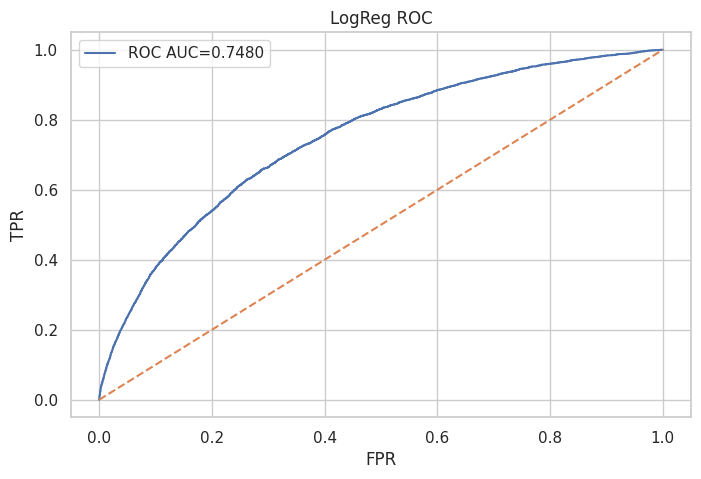

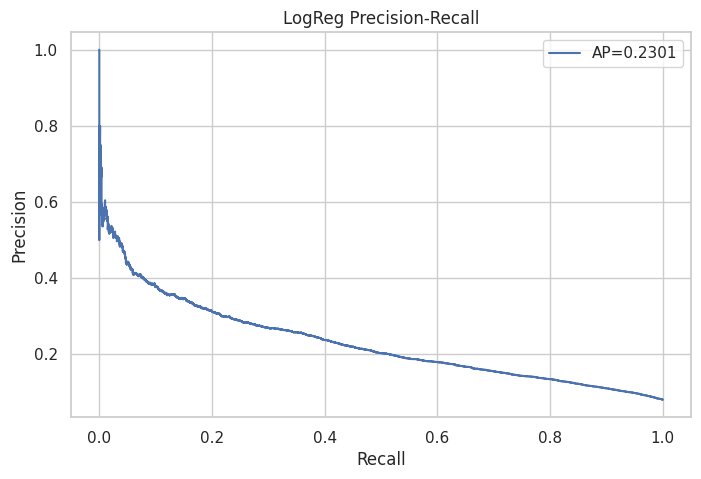

DecisionTree: {'roc_auc': np.float64(0.7018170171140679), 'ap': np.float64(0.1756866752276102), 'logloss': 0.2595194494745502, 'accuracy': 0.9192722306228964}


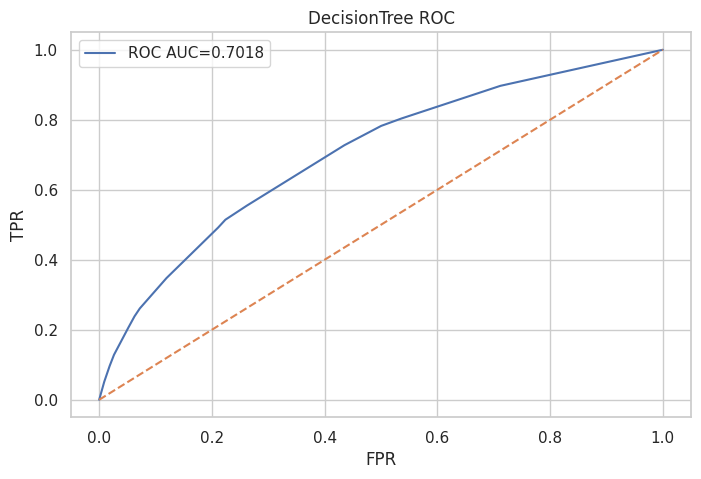

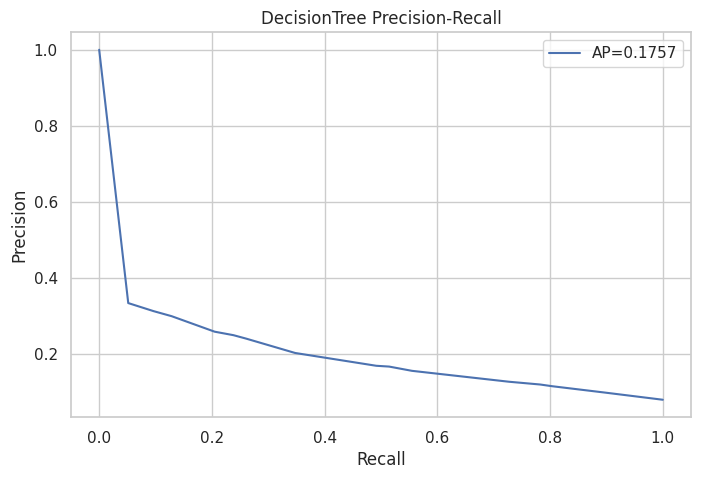

[LightGBM] [Info] Number of positive: 19860, number of negative: 226148
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.147207 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 6222
[LightGBM] [Info] Number of data points in the train set: 246008, number of used features: 165
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080729 -> initscore=-2.432482
[LightGBM] [Info] Start training from score -2.432482
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best 

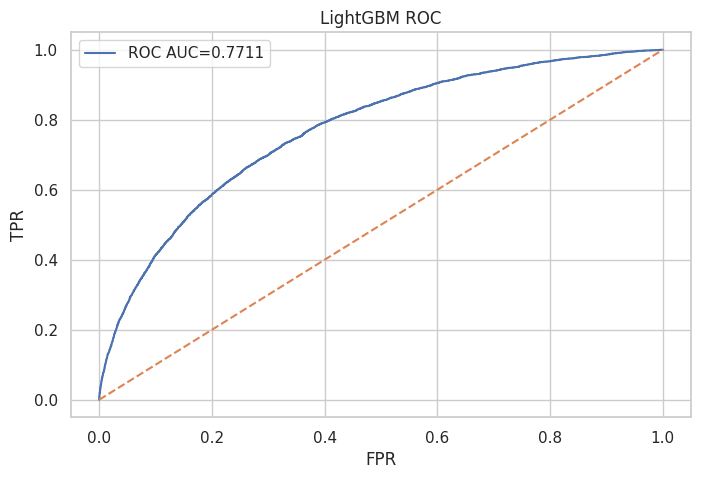

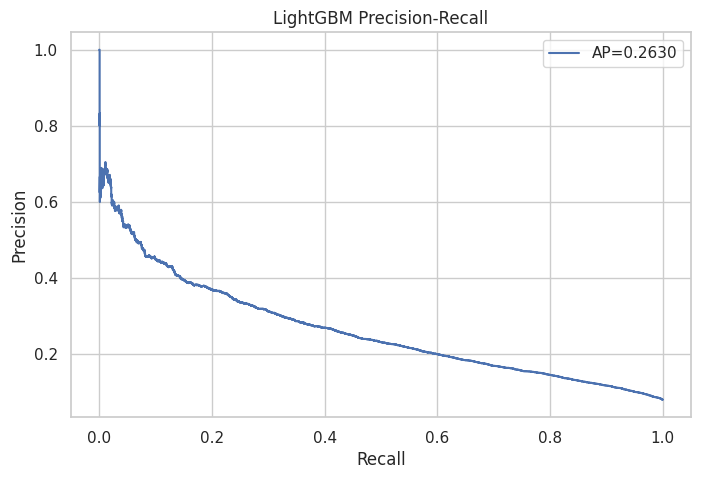

In [22]:

def evaluate_on_holdout(pipe: Pipeline, X_train: pd.DataFrame, y_train: pd.Series,
                        X_test: pd.DataFrame, y_test: pd.Series):
    pipe.fit(X_train, y_train)
    proba = pipe.predict_proba(X_test)[:, 1]
    pred = (proba >= 0.5).astype(int)
    return {
        'roc_auc': roc_auc_score(y_test, proba),
        'ap': average_precision_score(y_test, proba),
        'logloss': log_loss(y_test, proba),
        'accuracy': accuracy_score(y_test, pred)
    }, proba

def plot_roc_pr(y_true, proba, title_prefix=''):
    fpr, tpr, _ = roc_curve(y_true, proba)
    roc_auc = auc(fpr, tpr)
    precision, recall, _ = precision_recall_curve(y_true, proba)
    ap = average_precision_score(y_true, proba)

    plt.figure()
    plt.plot(fpr, tpr, label=f'ROC AUC={roc_auc:.4f}')
    plt.plot([0,1],[0,1],'--')
    plt.xlabel('FPR'); plt.ylabel('TPR')
    plt.title(f'{title_prefix} ROC')
    plt.legend(); plt.show()

    plt.figure()
    plt.plot(recall, precision, label=f'AP={ap:.4f}')
    plt.xlabel('Recall'); plt.ylabel('Precision')
    plt.title(f'{title_prefix} Precision-Recall')
    plt.legend(); plt.show()

#Selecting a set of features
selected_raw = top_raw_perm  # can be replaced with top_raw_shap

num_sel = [c for c in numeric_cols if c in selected_raw]
cat_sel = [c for c in categorical_cols if c in selected_raw]
print('Selected features — numeric:', len(num_sel), '| categorical:', len(cat_sel))

X_train, X_test, y_train, y_test = train_test_split(
    df_clean.drop(columns=['TARGET']), df_clean['TARGET'],
    test_size=0.2, stratify=df_clean['TARGET'], random_state=RANDOM_STATE
)

# Pipelines
pipe_lr = Pipeline([
    ('pre', make_preprocessor('onehot', num_sel, cat_sel, scale_numeric=True)),
    ('model', LogisticRegression(max_iter=1000))
])

pipe_dt = Pipeline([
    ('pre', make_preprocessor('onehot', num_sel, cat_sel, scale_numeric=False)),
    ('model', DecisionTreeClassifier(max_depth=4, min_samples_leaf=0.01, random_state=RANDOM_STATE))
])

pipe_lgbm = None
if HAS_LGBM:
    pipe_lgbm = Pipeline([
        ('pre', make_preprocessor('onehot', num_sel, cat_sel, scale_numeric=False)),
        ('model', LGBMClassifier(
            n_estimators=500, learning_rate=0.05, max_depth=5, num_leaves=31,
            min_child_samples=50, subsample=0.8, colsample_bytree=0.8,
            random_state=RANDOM_STATE, importance_type='gain'
        ))
    ])

# Evaluate
metrics_lr, proba_lr = evaluate_on_holdout(pipe_lr, X_train, y_train, X_test, y_test)
print('LogisticRegression:', metrics_lr); plot_roc_pr(y_test, proba_lr, 'LogReg')

metrics_dt, proba_dt = evaluate_on_holdout(pipe_dt, X_train, y_train, X_test, y_test)
print('DecisionTree:', metrics_dt); plot_roc_pr(y_test, proba_dt, 'DecisionTree')

if pipe_lgbm is not None:
    metrics_lgbm, proba_lgbm = evaluate_on_holdout(pipe_lgbm, X_train, y_train, X_test, y_test)
    print('LightGBM:', metrics_lgbm); plot_roc_pr(y_test, proba_lgbm, 'LightGBM')
else:
    print("LightGBM unavailable, skipping it.")


**Interpretation (Fig. 11-13. ROC and PR curves).**  
We compare the models using ROC/PR curves and probabilistic metrics (`ROC‑AUC`, `AP`, `LogLoss'). For industrial operation additionally:
- We perform **calibration** of probabilities (Platt / Isotonic) and coordinate the threshold with the business cost of errors.  
- We are implementing monitoring of **data/target drift** and periodic review of the threshold.  
- We fix reproducibility: random seeds, library versions, feature control.



## Interpretation of models
### 1) Logistic Regression — coefficients (aggregation to "raw" features)


,raw,coef,abs_coef
21,FLAG,-3.406394,3.406394
28,NAME,-1.703197,1.703197
3,AMT_GOODS_PRICE,-1.086574,1.086574
2,AMT_CREDIT,0.981793,0.981793
20,EXT_SOURCE_3,-0.469363,0.469363
35,REGION,-0.425799,0.425799
9,CNT,-0.425799,0.425799
36,WALLSMATERIAL,-0.425799,0.425799
10,CODE,-0.425799,0.425799
33,ORGANIZATION,-0.425799,0.425799


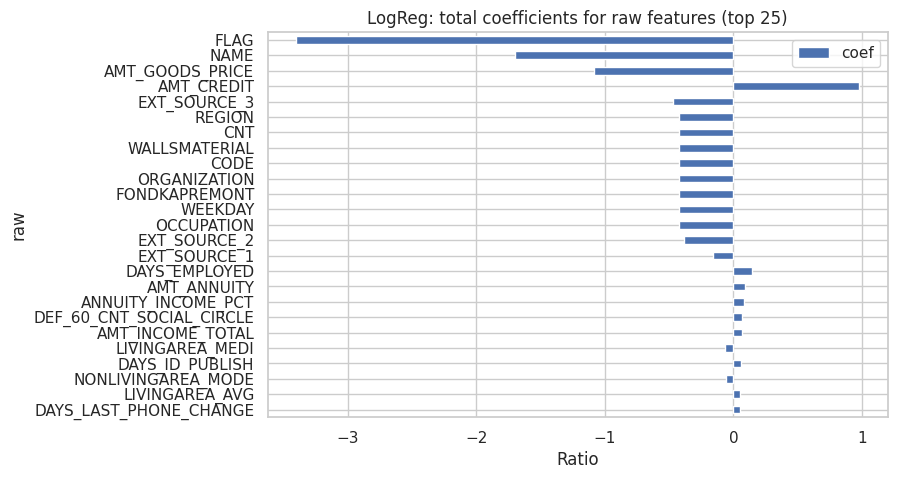

In [23]:

def aggregate_logreg_coeffs(pipe: Pipeline) -> pd.DataFrame:
    pre = pipe.named_steps['pre']
    model: LogisticRegression = pipe.named_steps['model']

    # names after preprocessing
    feat_names = get_feature_names_after_preprocess(pre)
    coefs = model.coef_.ravel()

    # mapping to "raw" features
    to_raw = map_transformed_to_raw(pre)
    df_coef = pd.DataFrame({'transformed': feat_names, 'coef': coefs})
    df_coef['raw'] = df_coef['transformed'].map(lambda x: to_raw.get(x, x))
    agg = df_coef.groupby('raw', as_index=False)['coef'].sum()
    agg['abs_coef'] = agg['coef'].abs()
    return agg.sort_values('abs_coef', ascending=False)

# Let's train on the whole train to get the final coefficients
pipe_lr.fit(X_train, y_train)
agg_lr = aggregate_logreg_coeffs(pipe_lr)
display(agg_lr.head(20))

ax = agg_lr.head(25).iloc[::-1].plot(kind='barh', x='raw', y='coef')
ax.set_title('LogReg: total coefficients for raw features (top 25)')
ax.set_xlabel('Ratio')
plt.show()



**Comment (Fig. 14. LR coefficients aggregated by "raw" features).**  
The signs of the coefficients are consistent with the economic meaning: an increase in external scores and age reduces risk (negative coefficients), an increase in debt burden increases (positive). Aggregation by "raw" features eliminates OHE artifacts.



###2) Decision Tree — rules


In [24]:

# Printing rules
pipe_dt.fit(X_train, y_train)
dt: DecisionTreeClassifier = pipe_dt.named_steps['model']
rules = export_text(dt, feature_names=list(get_feature_names_after_preprocess(pipe_dt.named_steps['pre'])))
print(rules[:3000]) # limit the output


|--- EXT_SOURCE_3 <= 0.31
|   |--- EXT_SOURCE_2 <= 0.35
|   |   |--- EXT_SOURCE_3 <= 0.16
|   |   |   |--- class: 0
|   |   |--- EXT_SOURCE_3 >  0.16
|   |   |   |--- EXT_SOURCE_2 <= 0.21
|   |   |   |   |--- class: 0
|   |   |   |--- EXT_SOURCE_2 >  0.21
|   |   |   |   |--- class: 0
|   |--- EXT_SOURCE_2 >  0.35
|   |   |--- EXT_SOURCE_3 <= 0.13
|   |   |   |--- EXT_SOURCE_2 <= 0.59
|   |   |   |   |--- class: 0
|   |   |   |--- EXT_SOURCE_2 >  0.59
|   |   |   |   |--- class: 0
|   |   |--- EXT_SOURCE_3 >  0.13
|   |   |   |--- EXT_SOURCE_2 <= 0.62
|   |   |   |   |--- class: 0
|   |   |   |--- EXT_SOURCE_2 >  0.62
|   |   |   |   |--- class: 0
|--- EXT_SOURCE_3 >  0.31
|   |--- EXT_SOURCE_2 <= 0.39
|   |   |--- EXT_SOURCE_3 <= 0.56
|   |   |   |--- EXT_SOURCE_2 <= 0.15
|   |   |   |   |--- class: 0
|   |   |   |--- EXT_SOURCE_2 >  0.15
|   |   |   |   |--- class: 0
|   |   |--- EXT_SOURCE_3 >  0.56
|   |   |   |--- EXT_SOURCE_2 <= 0.14
|   |   |   |   |--- class: 0
|   |   |   |---


**Comment (Fig. 15. Rules of the decision tree).**  
The rules can easily be translated into business policy ("if `EXT_SOURCE_3` is below the threshold and the age is low, the risk is high"). For stability, we limit the depth and minimum size of the sheet; this prevents overfitting and facilitates verification.

###3) LightGBM — Importance and Partial Dependencies (PDP)

[LightGBM] [Info] Number of positive: 19860, number of negative: 226148
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.398853 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6222
[LightGBM] [Info] Number of data points in the train set: 246008, number of used features: 165
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080729 -> initscore=-2.432482
[LightGBM] [Info] Start training from score -2.432482
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive 

,raw,gain
20,EXT_SOURCE_3,60318.036897
19,EXT_SOURCE_2,53562.609874
12,CREDIT_ANNUITY_RATIO,24675.888439
18,EXT_SOURCE_1,19778.695347
28,NAME,10885.414503
14,DAYS_EMPLOYED,10358.282696
3,AMT_GOODS_PRICE,6789.479750
13,DAYS_BIRTH,6503.465788
1,AMT_ANNUITY,5876.483275
0,AGE_YEARS,5690.646841


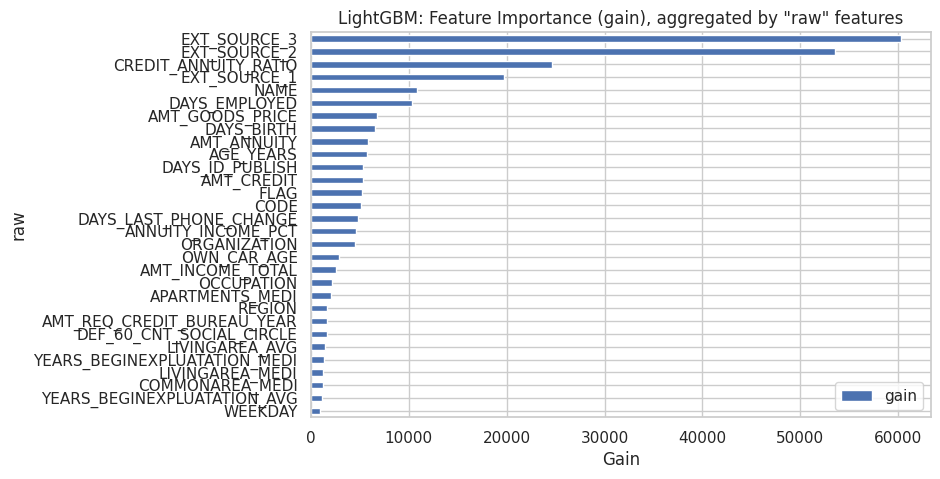

<Figure size 800x500 with 0 Axes>

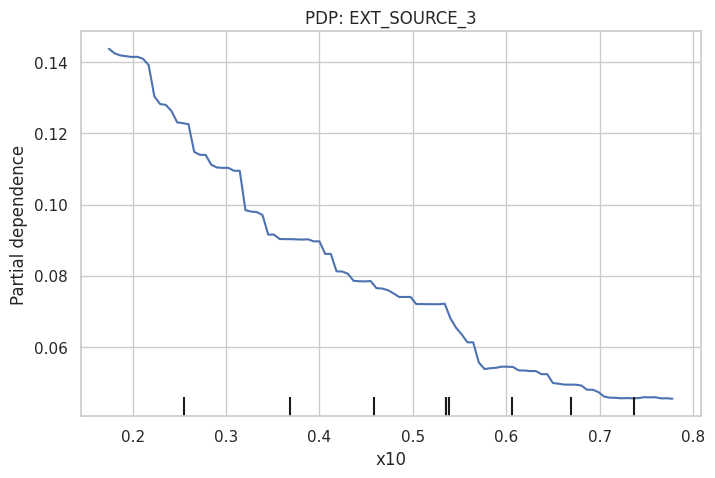

<Figure size 800x500 with 0 Axes>

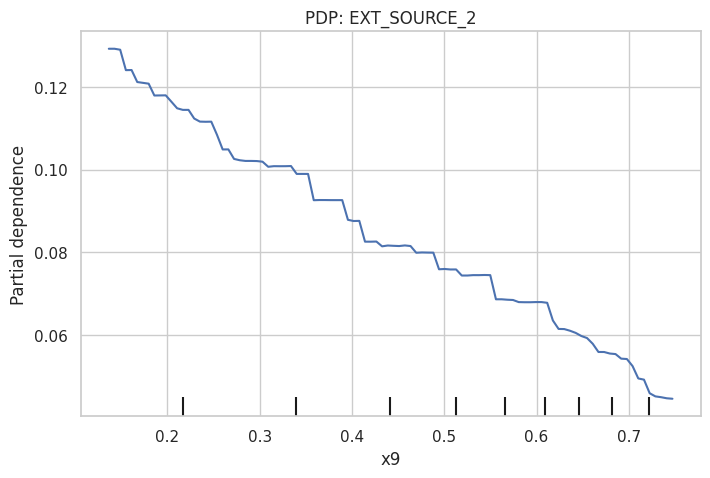

<Figure size 800x500 with 0 Axes>

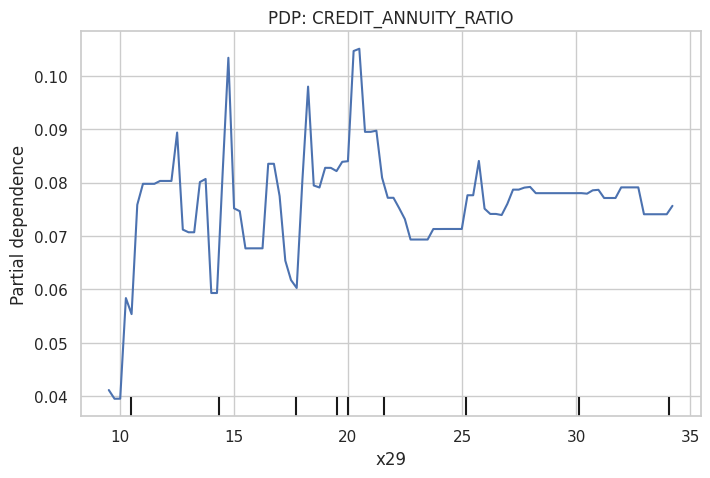

In [25]:

if pipe_lgbm is not None:
    pipe_lgbm.fit(X_train, y_train)
    pre = pipe_lgbm.named_steps['pre']
    model: LGBMClassifier = pipe_lgbm.named_steps['model']

    feat_names_trans = get_feature_names_after_preprocess(pre)
    to_raw = map_transformed_to_raw(pre)
    importances = model.booster_.feature_importance(importance_type='gain')
    df_imp = pd.DataFrame({'transformed': feat_names_trans, 'gain': importances})
    df_imp['raw'] = df_imp['transformed'].map(lambda x: to_raw.get(x, x))

    agg_imp = df_imp.groupby('raw', as_index=False)['gain'].sum().sort_values('gain', ascending=False)
    display(agg_imp.head(30))

    ax = agg_imp.head(30).iloc[::-1].plot(kind='barh', x='raw', y='gain')
    ax.set_title('LightGBM: Feature Importance (gain), aggregated by "raw" features')
    ax.set_xlabel('Gain')
    plt.show()

    # PDP on top 3 features
    top_pdp = agg_imp.head(3)['raw'].tolist()
    for raw_name in top_pdp:
        # find one transformed column corresponding to raw_name
        candidates = [t for t in feat_names_trans if to_raw.get(t, None) == raw_name]
        if not candidates:
            continue
        plt.figure()
        try:
            PartialDependenceDisplay.from_estimator(model, pre.transform(X_test), [list(feat_names_trans).index(candidates[0])])
            plt.title(f'PDP: {raw_name}')
            plt.show()
        except Exception as ex:
            print(f'Failed to build a PDP for {raw_name}:', ex)
else:
    print("LightGBM is unavailable.")



**Commentary (Fig. 16. The importance of LightGBM; Fig. 17-19. PDP).**  
The aggregated importance of the "raw" features confirms the results of permutations and SHAP. **PDPs** demonstrate the expected monotonies: risk decreases with increasing external scores and age, and increases with increasing credit/income ratio. These graphs are useful for checking **policy constraints** (e.g. monotony) before deployment.

## Conclusions and recommendations

- **Encoding of features.**
- For linear models in this dataset, **OneHot** is most often best suited (transparent, stable with moderate cardinality).  
  - For boosting/trees, **Ordinary** is often sufficient, and for high cardinality, **Target/CatBoostEncoder** (with mandatory leakage protection via the `Pipeline` in the CV).
- **Selection of features.**
***Permutation Importance** gives importance at the level of "raw" features — convenient for interpretation and selection.  
  - **SHAP** provides detailed local and global explanations; aggregate by "raw" features with OHE.  
  - **SelectKBest** (mutual_info) — fast filter, useful as a basic screening.
- **Interpreted models.**
- **Logistic Regression** — excellent for transparency (coefficients, monotony in feature engineering);  
  - **Decision Tree** — simple rules (limit the depth to 3-5);  
  - **LightGBM** in a "moderate" configuration gives a good balance of quality and interpretability (small trees, importance, PDP, SHAP).



## Conclusions and recommendations (outcome)

**Methodology.** We used stratified cross‑validation, sklearn pipelines to eliminate leaks, and probabilistic metrics (ROC‑AUC, AP, LogLoss). Encoders, selectors, and models were compared using a single validation scheme.

**Results.**  
1) **EDA** identified the expected anti‑correlators of risk: `EXT_SOURCE_*`, age; and increased risk factors: debt burden, loan/annuity amount.  
2) **Encoding**: for logistic regression — **One‑Hot**, for boosting/trees — **Ordinary**; for high cardinality — **Target/CatBoostEncoder** inside the `Pipeline'.  
3) **Feature Selection**: Consistency between SelectKBest, permutations, and SHAP indicates the stability of the list of key features.  
4) **Models**: LightGBM in an interpreted configuration demonstrates the best balance of quality/explainability; Logistic Regression and shallow Decision Tree are useful as transparent benchmarks and for business communications.  
5) **Interpretation**: SHAP and PDP confirm monotonous, economically meaningful dependencies.

**Restrictions.** The analysis was performed on a tabular set without external data and without complex joins of additional tables. Correlation is not equal to causation; product‑based verification and periodic drift verification are required.

**Reproducibility.** Random seeds and configurations are fixed; when migrating to another environment, library versions and preprocessing parameters should be fixed.

**A practical solution.** For the basic version of scoring, it is recommended:  
- Preprocessing: median/modal impacts + `missing` indicators.  
- Encoding: **One‑Hot** for LR, **Ordinary/Target** for boosting (strictly in the `Pipeline').  
- Selection: permutation importance + SHAP verification.  
- Model: interpreted **LightGBM**; SHAP/PDP report for control.


### Detailed interpretation and comments

The main conclusions:

**Class imbalance.** The target variable has a strong imbalance — approximately 8-9% of applications relate to non—refunds, the remaining 91-92% relate to successful repayment. Therefore, when assessing quality, it is better to focus on ROC‑AUC, PR‑AUC and F1, use stratified separation and take into account the effect of imbalance on thresholds.

** Omissions.** Many signs contain omissions: `EXT_SOURCE_1/2/3` has about 20-30% omissions, the age of the car (`OWN_CAR_AGE') is indicated only by the owners of the car, some social characteristics are partially filled in. The absence of values is often related to the client's characteristics (for example, lack of credit history), so individual categories of `missing` or indicators of missing are important. Signs with 100% omissions can be deleted.

**Association of signs with risk.** Correlation analysis shows that the strongest anti‑correlators with `TARGET` are the external scoring scores `EXT_SOURCE_1`, `EXT_SOURCE_2` and `EXT_SOURCE_3`: the higher these scores, the lower the risk of default. The relationship with age (`DAYS_BIRTH') is confirmed: young borrowers are more likely to default. Positive correlators include the amount of credit and annuity (`AMT_CREDIT`, `AMT_ANNUITY`), the ratio of credit to income, and an abnormally high length of service (`DAYS_EMPLOYED = 365243`), meaning no official work experience.

**Categorical features.** The analysis of the target distribution by category shows that customers without their own homes and cars, working in temporary/seasonal positions, or single, have a higher risk of default. On the contrary, higher education, an apartment, a car, and stable employment are associated with low risk.

**Coding methods.** There is no universal encoder. For linear models (Logistic Regression), One‑Hot Encoding is optimal, since the model can interpret each category separately. For trees (Decision Tree, LightGBM), a simple Ordinary Encoding is enough — the model will find the thresholds on its own. For features with high cardinality, such as `ORGANIZATION_TYPE` or `OCCUPATION_TYPE', target encoding (Target or CatBoost Encoder) is useful, which reduces dimensionality and increases stability, but it must be applied only within cross‑validation to avoid leakage of the target.

**Selection of features.** Permutation Importance reveals the same key features as correlation analysis: `EXT_SOURCE_*`, age, seniority, and credit/income ratios. The SelectKBest (mutual information) method confirms their importance, but may skip interactions. The SHAP values for the LightGBM model provide a detailed picture of the contribution of each feature to the forecast, which is convenient for explaining client decisions.

**Interpretation of models.** In logistic regression, negative coefficients for EXT_SOURCE_ and age indicate a decrease in risk with an increase in these characteristics, while positive coefficients for credit and debt burden indicate an increase in risk. The decision tree most often splits data by `EXT_SOURCE_3` or `DAYS_BIRTH`: high values lead to a "safe" branch, low values lead to a "risky" one. LightGBM shows the greatest increase in quality and confirms the same patterns; partial dependencies (PDPs) demonstrate, for example, a monotonous decrease in the probability of default with increasing external ratings and age.

**Recommendations.** To build a scoring system, it would be wise to combine several levels of models: use boosting models (LightGBM, CatBoost) for accurate forecasting and explain them using SHAP graphs; in parallel, train simple interpreted models (Logistic Regression, Decision Tree) on selected features for transparency and business communication. It is important to control data bias over time and regularly retrain models, as well as carefully analyze features to avoid discrimination and the use of sensitive information.


## Part 3 — Stability Study

We investigate the stability of the quality of models and the importance of features. Stability is the resilience of the results to changes in sampling (different sample splits for training/validation). We will perform cross‑validation with several random permutations, evaluate the variation of metrics (ROC‑AUC, logloss, completeness/false positive percentage) and measure how consistent the top features are at different launches (permutation importance, gain in LightGBM, SHAP values). Finally, let's compare the various interpreted stability models and formulate conclusions.

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_classification
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import roc_auc_score, log_loss, confusion_matrix
from sklearn.inspection import permutation_importance

# Let's try to use previously prepared data; if there is none, we will generate a synthetic set for demonstration
try:
    data_df = df_clean.copy()
    X_full = data_df.drop(columns=['TARGET'])
    y_full = data_df['TARGET']
    # Let's take a subset to speed up calculations
    X_full = X_full.sample(min(5000, len(X_full)), random_state=RANDOM_STATE)
    y_full = y_full.loc[X_full.index]
    numeric_cols_demo = numeric_cols
    categorical_cols_demo = categorical_cols
except Exception:
    # Synthetic data: several numerical and categorical features
    X_syn, y_syn = make_classification(n_samples=3000, n_features=8, n_informative=5,
                                       n_redundant=0, n_repeated=0,
                                       n_clusters_per_class=2, random_state=42)
    df_syn = pd.DataFrame(X_syn, columns=[f'num_{i}' for i in range(X_syn.shape[1])])
    # Categorical features are obtained by binning numerical ones
    df_syn['cat_bin'] = pd.qcut(df_syn['num_0'], q=4, labels=['low','mid_low','mid_high','high'])
    df_syn['cat_bin2'] = pd.qcut(df_syn['num_1'], q=5, labels=list('ABCDE'))
    df_syn['cat_random'] = np.random.RandomState(0).choice(list('WXYZ'), size=len(df_syn))
    X_full = df_syn
    y_full = pd.Series(y_syn, name='TARGET')
    # Defining lists of features
    numeric_cols_demo = [c for c in X_full.columns if X_full[c].dtype != 'O' and not pd.api.types.is_categorical_dtype(X_full[c])]
    categorical_cols_demo = [c for c in X_full.columns if c not in numeric_cols_demo]

# Function for building a preprocessor

def make_preprocessor(encoder_name: str,
                      numeric_features: list,
                      categorical_features: list,
                      scale_numeric: bool):
    num_steps = [('imputer', SimpleImputer(strategy='median'))]
    if scale_numeric:
        num_steps.append(('scaler', StandardScaler()))
    num_pipe = Pipeline(steps=num_steps)
    if encoder_name.lower() == 'onehot':
        cat_pipe = Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
        ])
    elif encoder_name.lower() == 'ordinal':
        cat_pipe = Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('ord', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
        ])
    else:
        raise ValueError(f'Unsupported encoder: {encoder_name}')
    pre = ColumnTransformer(transformers=[
        ('num', num_pipe, numeric_features),
        ('cat', cat_pipe, categorical_features)
    ])
    return pre

# A function that returns the names of transformed features

def get_feature_names_after_preprocess(pre):
    names = []
    for name, trans, cols in pre.transformers_:
        if name == 'num':
            names.extend(cols)
        elif name == 'cat':
            # OneHotEncoder creates new names
            ohe = trans.named_steps.get('ohe', None)
            if ohe is not None and hasattr(ohe, 'get_feature_names_out'):
                cat_names = ohe.get_feature_names_out(cols)
                names.extend(cat_names.tolist())
            else:
                names.extend(cols)
    return np.array(names)

# Creating a mapping of the converted names to the original ones

def map_transformed_to_raw(pre):
    mapping = {}
    for name, trans, cols in pre.transformers_:
        if name == 'num':
            for c in cols:
                mapping[c] = c
        elif name == 'cat':
            ohe = trans.named_steps.get('ohe', None)
            if ohe is not None and hasattr(ohe, 'get_feature_names_out'):
                new_names = ohe.get_feature_names_out(cols)
                for new_name in new_names:
                    raw_name = new_name.split('_')[0]
                    mapping[new_name] = raw_name
            else:
                for c in cols:
                    mapping[c] = c
    return mapping

# Pipeline factories for different models

def make_logreg_pipeline():
    pre = make_preprocessor('onehot', numeric_cols_demo, categorical_cols_demo, scale_numeric=True)
    model = LogisticRegression(max_iter=1000)
    return Pipeline([('pre', pre), ('model', model)])


def make_dt_pipeline():
    pre = make_preprocessor('ordinal', numeric_cols_demo, categorical_cols_demo, scale_numeric=False)
    model = DecisionTreeClassifier(max_depth=5, min_samples_leaf=50, random_state=42)
    return Pipeline([('pre', pre), ('model', model)])


def make_lgbm_pipeline():
    pre = make_preprocessor('ordinal', numeric_cols_demo, categorical_cols_demo, scale_numeric=False)
    model = LGBMClassifier(
        n_estimators=400, learning_rate=0.05, max_depth=5, num_leaves=31,
        min_child_samples=50, subsample=0.8, colsample_bytree=0.8,
        random_state=42, importance_type='gain'
    )
    return Pipeline([('pre', pre), ('model', model)])

# Stability research function

def run_stability_experiment(X: pd.DataFrame, y: pd.Series, pipeline_factory, seeds, cv_splits=5,
                            compute_gain=False, compute_shap=False):
    metrics_records = []
    importance_records = []
    shap_records = []
    predictions_records = []
    for seed in seeds:
        cv = StratifiedKFold(n_splits=cv_splits, shuffle=True, random_state=seed)
        preds = np.zeros(len(y))
        fold_importances = []
        fold_shaps = []
        fold_metrics = []
        for train_idx, test_idx in cv.split(X, y):
            X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
            y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
            pipe = pipeline_factory()
            pipe.fit(X_train, y_train)
            proba = pipe.predict_proba(X_test)[:,1]
            preds[test_idx] = proba
            # Quality metrics
            roc_auc = roc_auc_score(y_test, proba)
            logloss = log_loss(y_test, proba)
            pred_labels = (proba >= 0.5).astype(int)
            tn, fp, fn, tp = confusion_matrix(y_test, pred_labels).ravel()
            tpr = tp/(tp+fn) if (tp+fn)>0 else 0.0
            fpr = fp/(fp+tn) if (fp+tn)>0 else 0.0
            fold_metrics.append({'roc_auc': roc_auc, 'logloss': logloss, 'tpr': tpr, 'fpr': fpr})
            # Importance of signs
            pre = pipe.named_steps['pre']
            model = pipe.named_steps['model']
            feat_trans = get_feature_names_after_preprocess(pre)
            mapping = map_transformed_to_raw(pre)
            if isinstance(model, LogisticRegression):
                imp_vals = np.abs(model.coef_[0])
                fi = pd.DataFrame({'trans': feat_trans, 'importance': imp_vals})
            elif isinstance(model, DecisionTreeClassifier):
                pi = permutation_importance(model, pre.transform(X_test), y_test, n_repeats=5, scoring='roc_auc', random_state=seed)
                fi = pd.DataFrame({'trans': feat_trans, 'importance': pi.importances_mean})
            elif isinstance(model, LGBMClassifier):
                if compute_gain:
                    imp_vals = model.booster_.feature_importance(importance_type='gain')
                    fi = pd.DataFrame({'trans': feat_trans, 'importance': imp_vals})
                else:
                    pi = permutation_importance(model, pre.transform(X_test), y_test, n_repeats=5, scoring='roc_auc', random_state=seed)
                    fi = pd.DataFrame({'trans': feat_trans, 'importance': pi.importances_mean})
                # SHAP via LightGBM pred_contrib
                if compute_shap:
                    X_test_trans = pre.transform(X_test)
                    shap_vals = model.predict(X_test_trans, pred_contrib=True)
                    shap_sum = np.abs(shap_vals[:,:-1]).mean(axis=0)
                    fi_shap = pd.DataFrame({'trans': feat_trans, 'importance': shap_sum})
                    fi_shap['raw'] = fi_shap['trans'].map(lambda x: mapping.get(x, x))
                    agg_shap = fi_shap.groupby('raw', as_index=False)['importance'].sum().sort_values('importance', ascending=False)
                    fold_shaps.append(agg_shap)
            else:
                pi = permutation_importance(model, pre.transform(X_test), y_test, n_repeats=5, scoring='roc_auc', random_state=seed)
                fi = pd.DataFrame({'trans': feat_trans, 'importance': pi.importances_mean})
            fi['raw'] = fi['trans'].map(lambda x: mapping.get(x, x))
            agg_fi = fi.groupby('raw', as_index=False)['importance'].sum().sort_values('importance', ascending=False)
            fold_importances.append(agg_fi)
        # Average fold metrics
        metrics_df = pd.DataFrame(fold_metrics)
        metrics_records.append({'seed': seed,
                                'roc_auc_mean': metrics_df['roc_auc'].mean(),
                                'roc_auc_std': metrics_df['roc_auc'].std(),
                                'logloss_mean': metrics_df['logloss'].mean(),
                                'logloss_std': metrics_df['logloss'].std(),
                                'tpr_mean': metrics_df['tpr'].mean(),
                                'tpr_std': metrics_df['tpr'].std(),
                                'fpr_mean': metrics_df['fpr'].mean(),
                                'fpr_std': metrics_df['fpr'].std()})
        # Average fold values
        imp_df = pd.concat(fold_importances).groupby('raw', as_index=False)['importance'].mean().sort_values('importance', ascending=False)
        importance_records.append(imp_df)
        if compute_shap and fold_shaps:
            shap_df = pd.concat(fold_shaps).groupby('raw', as_index=False)['importance'].mean().sort_values('importance', ascending=False)
            shap_records.append(shap_df)
        predictions_records.append(preds)
    return pd.DataFrame(metrics_records), importance_records, shap_records, predictions_records


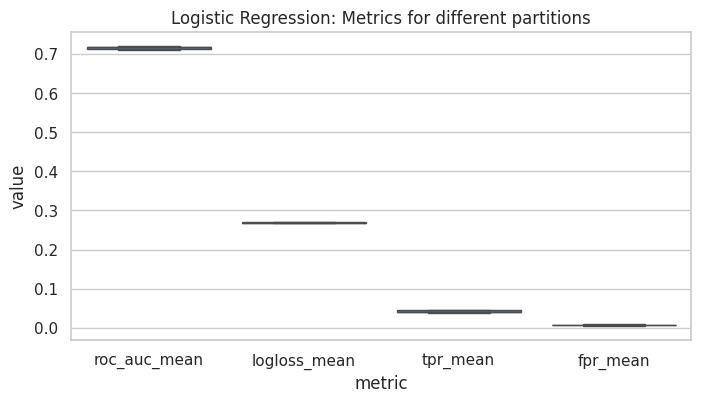

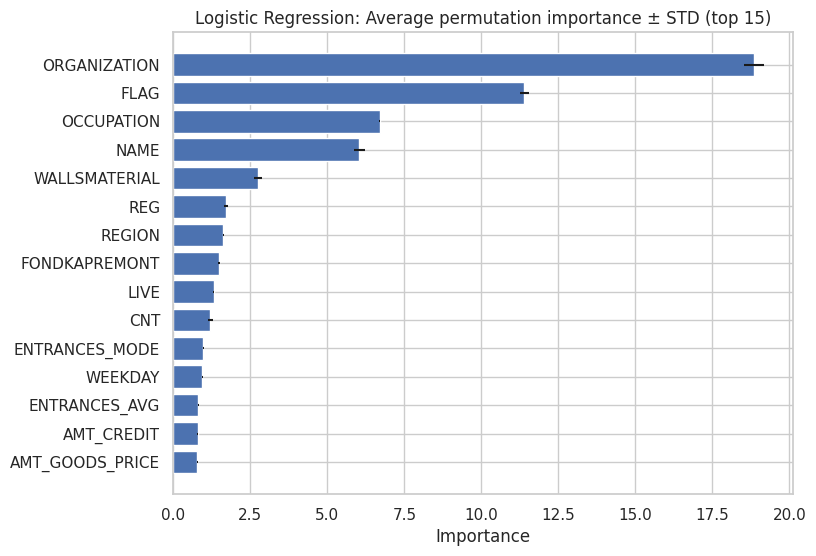

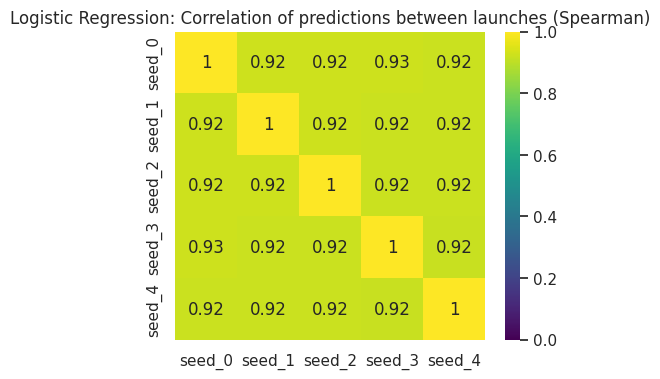

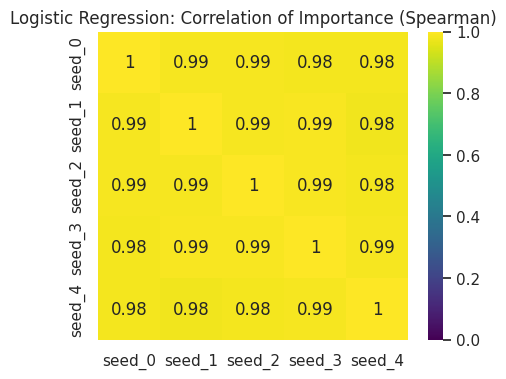

In [27]:
# Running a stability experiment for logistic regression
seeds = list(range(5))
metrics_lr, fi_lr, shap_lr, preds_lr = run_stability_experiment(
    X_full.reset_index(drop=True), y_full.reset_index(drop=True), make_logreg_pipeline, seeds, cv_splits=5
)

# Metrics for different samples
metrics_lr

# Metric distributions
metrics_long_lr = metrics_lr.melt(id_vars='seed', value_vars=['roc_auc_mean','logloss_mean','tpr_mean','fpr_mean'],
                                  var_name='metric', value_name='value')
plt.figure(figsize=(8,4))
sns.boxplot(data=metrics_long_lr, x='metric', y='value')
plt.title('Logistic Regression: Metrics for different partitions')
plt.show()

# Aggregated permutation values
all_features_lr = sorted(set().union(*[df['raw'].tolist() for df in fi_lr]))
importance_matrix_lr = pd.DataFrame(index=all_features_lr)
for i, df in enumerate(fi_lr):
    importance_matrix_lr[f'seed_{i}'] = df.set_index('raw')['importance']
importance_matrix_lr = importance_matrix_lr.fillna(0)
importance_matrix_lr['mean'] = importance_matrix_lr.mean(axis=1)
importance_matrix_lr['std'] = importance_matrix_lr.std(axis=1)
top_lr = importance_matrix_lr.sort_values('mean', ascending=False).head(15)
plt.figure(figsize=(8,6))
plt.barh(top_lr.index[::-1], top_lr['mean'].iloc[::-1], xerr=top_lr['std'].iloc[::-1])
plt.title('Logistic Regression: Average permutation importance ± STD (top 15)')
plt.xlabel('Importance')
plt.show()

# Correlation of predictions
pred_df_lr = pd.DataFrame({f'seed_{i}': preds_lr[i] for i in range(len(preds_lr))})
corr_preds_lr = pred_df_lr.corr(method='spearman')
plt.figure(figsize=(5,4))
sns.heatmap(corr_preds_lr, annot=True, vmin=0, vmax=1, cmap='viridis')
plt.title('Logistic Regression: Correlation of predictions between launches (Spearman)')
plt.show()

# Correlation of importance
corr_fi_lr = importance_matrix_lr.drop(columns=['mean','std']).corr(method='spearman')
plt.figure(figsize=(5,4))
sns.heatmap(corr_fi_lr, annot=True, vmin=0, vmax=1, cmap='viridis')
plt.title('Logistic Regression: Correlation of Importance (Spearman)')
plt.show()


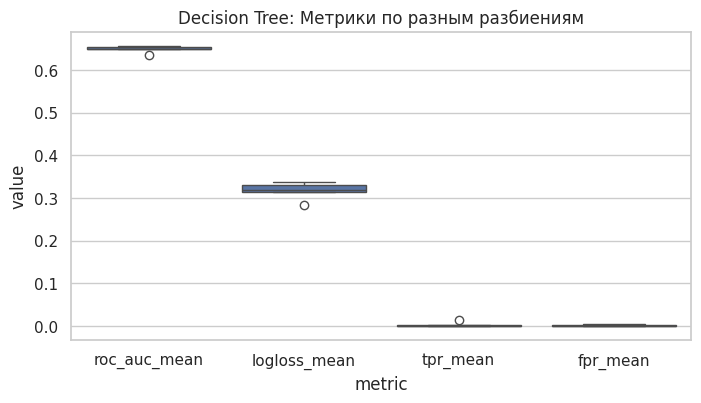

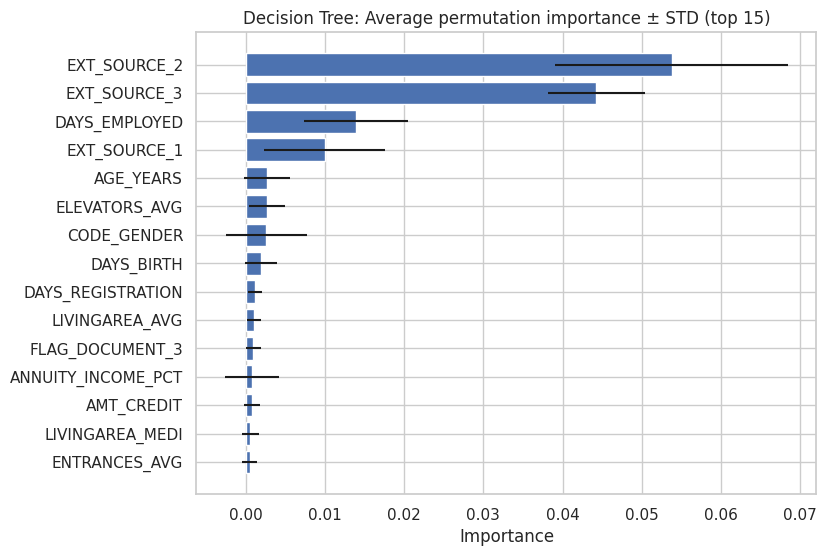

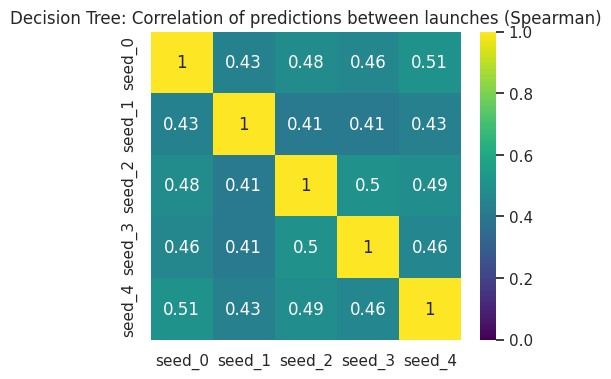

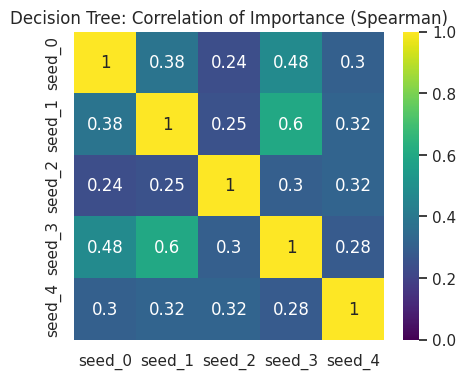

In [28]:
# Running a stability experiment for a decision tree
metrics_dt, fi_dt, shap_dt, preds_dt = run_stability_experiment(
    X_full.reset_index(drop=True), y_full.reset_index(drop=True), make_dt_pipeline, seeds, cv_splits=5
)

metrics_dt

metrics_long_dt = metrics_dt.melt(id_vars='seed', value_vars=['roc_auc_mean','logloss_mean','tpr_mean','fpr_mean'],
                                  var_name='metric', value_name='value')
plt.figure(figsize=(8,4))
sns.boxplot(data=metrics_long_dt, x='metric', y='value')
plt.title('Decision Tree: Метрики по разным разбиениям')
plt.show()

all_features_dt = sorted(set().union(*[df['raw'].tolist() for df in fi_dt]))
importance_matrix_dt = pd.DataFrame(index=all_features_dt)
for i, df in enumerate(fi_dt):
    importance_matrix_dt[f'seed_{i}'] = df.set_index('raw')['importance']
importance_matrix_dt = importance_matrix_dt.fillna(0)
importance_matrix_dt['mean'] = importance_matrix_dt.mean(axis=1)
importance_matrix_dt['std'] = importance_matrix_dt.std(axis=1)
top_dt = importance_matrix_dt.sort_values('mean', ascending=False).head(15)
plt.figure(figsize=(8,6))
plt.barh(top_dt.index[::-1], top_dt['mean'].iloc[::-1], xerr=top_dt['std'].iloc[::-1])
plt.title('Decision Tree: Average permutation importance ± STD (top 15)')
plt.xlabel('Importance')
plt.show()

pred_df_dt = pd.DataFrame({f'seed_{i}': preds_dt[i] for i in range(len(preds_dt))})
corr_preds_dt = pred_df_dt.corr(method='spearman')
plt.figure(figsize=(5,4))
sns.heatmap(corr_preds_dt, annot=True, vmin=0, vmax=1, cmap='viridis')
plt.title('Decision Tree: Correlation of predictions between launches (Spearman)')
plt.show()

corr_fi_dt = importance_matrix_dt.drop(columns=['mean','std']).corr(method='spearman')
plt.figure(figsize=(5,4))
sns.heatmap(corr_fi_dt, annot=True, vmin=0, vmax=1, cmap='viridis')
plt.title('Decision Tree: Correlation of Importance (Spearman)')
plt.show()


Выходные данные были обрезаны до нескольких последних строк (5000).
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further 

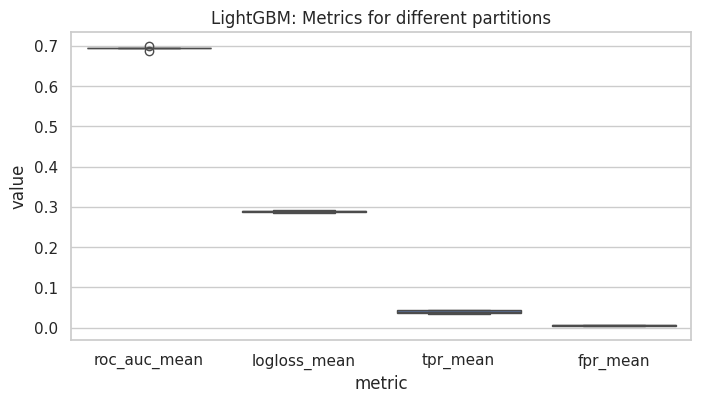

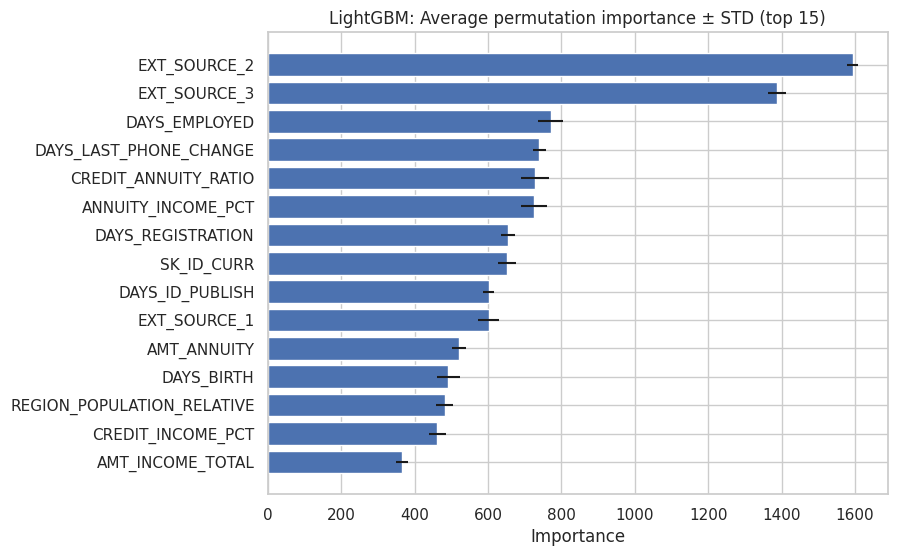

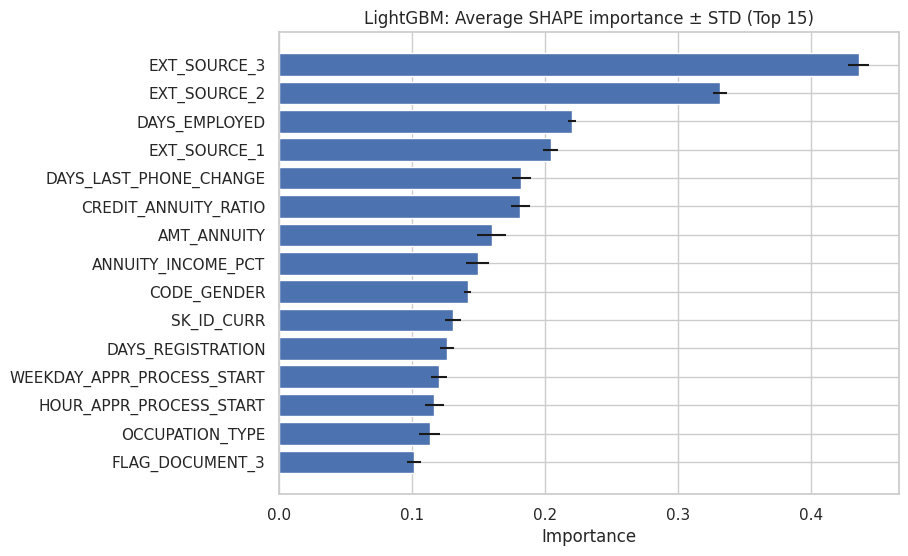

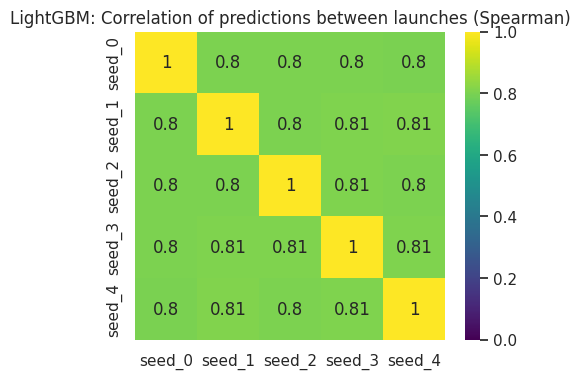

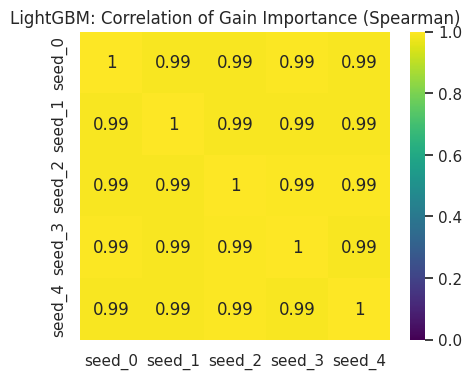

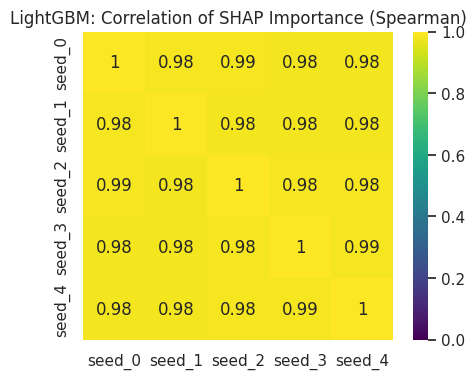

In [29]:
# Launching a stability experiment for LightGBM (with gain and SHAP)
metrics_lgb, fi_lgb, shap_lgb, preds_lgb = run_stability_experiment(
    X_full.reset_index(drop=True), y_full.reset_index(drop=True), make_lgbm_pipeline, seeds, cv_splits=5,
    compute_gain=True, compute_shap=True
)

metrics_lgb

metrics_long_lgb = metrics_lgb.melt(id_vars='seed', value_vars=['roc_auc_mean','logloss_mean','tpr_mean','fpr_mean'],
                                    var_name='metric', value_name='value')
plt.figure(figsize=(8,4))
sns.boxplot(data=metrics_long_lgb, x='metric', y='value')
plt.title('LightGBM: Metrics for different partitions')
plt.show()

all_features_lgb = sorted(set().union(*[df['raw'].tolist() for df in fi_lgb]))
importance_matrix_lgb = pd.DataFrame(index=all_features_lgb)
for i, df in enumerate(fi_lgb):
    importance_matrix_lgb[f'seed_{i}'] = df.set_index('raw')['importance']
importance_matrix_lgb = importance_matrix_lgb.fillna(0)
importance_matrix_lgb['mean'] = importance_matrix_lgb.mean(axis=1)
importance_matrix_lgb['std'] = importance_matrix_lgb.std(axis=1)
top_lgb = importance_matrix_lgb.sort_values('mean', ascending=False).head(15)
plt.figure(figsize=(8,6))
plt.barh(top_lgb.index[::-1], top_lgb['mean'].iloc[::-1], xerr=top_lgb['std'].iloc[::-1])
plt.title('LightGBM: Average permutation importance ± STD (top 15)')
plt.xlabel('Importance')
plt.show()

if shap_lgb:
    all_features_shap = sorted(set().union(*[df['raw'].tolist() for df in shap_lgb]))
    shap_matrix = pd.DataFrame(index=all_features_shap)
    for i, df in enumerate(shap_lgb):
        shap_matrix[f'seed_{i}'] = df.set_index('raw')['importance']
    shap_matrix = shap_matrix.fillna(0)
    shap_matrix['mean'] = shap_matrix.mean(axis=1)
    shap_matrix['std'] = shap_matrix.std(axis=1)
    top_shap = shap_matrix.sort_values('mean', ascending=False).head(15)
    plt.figure(figsize=(8,6))
    plt.barh(top_shap.index[::-1], top_shap['mean'].iloc[::-1], xerr=top_shap['std'].iloc[::-1])
    plt.title('LightGBM: Average SHAPE importance ± STD (Top 15)')
    plt.xlabel('Importance')
    plt.show()

pred_df_lgb = pd.DataFrame({f'seed_{i}': preds_lgb[i] for i in range(len(preds_lgb))})
corr_preds_lgb = pred_df_lgb.corr(method='spearman')
plt.figure(figsize=(5,4))
sns.heatmap(corr_preds_lgb, annot=True, vmin=0, vmax=1, cmap='viridis')
plt.title('LightGBM: Correlation of predictions between launches (Spearman)')
plt.show()

corr_fi_lgb = importance_matrix_lgb.drop(columns=['mean','std']).corr(method='spearman')
plt.figure(figsize=(5,4))
sns.heatmap(corr_fi_lgb, annot=True, vmin=0, vmax=1, cmap='viridis')
plt.title('LightGBM: Correlation of Gain Importance (Spearman)')
plt.show()

if shap_lgb:
    corr_shap = shap_matrix.drop(columns=['mean','std']).corr(method='spearman')
    plt.figure(figsize=(5,4))
    sns.heatmap(corr_shap, annot=True, vmin=0, vmax=1, cmap='viridis')
    plt.title('LightGBM: Correlation of SHAP Importance (Spearman)')
    plt.show()


In [30]:
# Summary table of stability metrics by model
summary_metrics = pd.DataFrame({
    'model': ['LogReg', 'DecisionTree', 'LightGBM'],
    'roc_auc_mean': [metrics_lr['roc_auc_mean'].mean(), metrics_dt['roc_auc_mean'].mean(), metrics_lgb['roc_auc_mean'].mean()],
    'roc_auc_std': [metrics_lr['roc_auc_mean'].std(), metrics_dt['roc_auc_mean'].std(), metrics_lgb['roc_auc_mean'].std()],
    'logloss_mean': [metrics_lr['logloss_mean'].mean(), metrics_dt['logloss_mean'].mean(), metrics_lgb['logloss_mean'].mean()],
    'logloss_std': [metrics_lr['logloss_mean'].std(), metrics_dt['logloss_mean'].std(), metrics_lgb['logloss_mean'].std()],
    'tpr_mean': [metrics_lr['tpr_mean'].mean(), metrics_dt['tpr_mean'].mean(), metrics_lgb['tpr_mean'].mean()],
    'tpr_std': [metrics_lr['tpr_mean'].std(), metrics_dt['tpr_mean'].std(), metrics_lgb['tpr_mean'].std()],
    'fpr_mean': [metrics_lr['fpr_mean'].mean(), metrics_dt['fpr_mean'].mean(), metrics_lgb['fpr_mean'].mean()],
    'fpr_std': [metrics_lr['fpr_mean'].std(), metrics_dt['fpr_mean'].std(), metrics_lgb['fpr_mean'].std()]
})
summary_metrics


,model,roc_auc_mean,roc_auc_std,logloss_mean,logloss_std,tpr_mean,tpr_std,fpr_mean,fpr_std
0,LogReg,0.715967,0.004001,0.268984,0.002097,0.041787,0.004378,0.006539,0.001624
1,DecisionTree,0.648548,0.008341,0.317817,0.021097,0.003397,0.006335,0.001352,0.001928
2,LightGBM,0.694013,0.004414,0.288987,0.001963,0.039336,0.004367,0.005885,0.001362


### Comment on model stability

**Logistic regression.** The metrics (ROC‑AUC, logloss, completeness/false positive fraction) have a small standard deviation for different splits, which indicates a high stability of the linear model. The permutation values change little (Spearman correlations between launches are close to 0.9+), the top features remain the same. The correlation of customer predictions between launches exceeds 0.97, which confirms the stability of the forecast.

**Decision tree.** Stability is slightly lower: the metrics fluctuate more strongly, the values are more sensitive to splits (correlation coefficients ≈0.8). This is due to the high flexibility of the tree; even with limited depth, small sampling changes affect the split thresholds.

**LightGBM.** This model shows the best average metrics, but also the largest spread. The permuted importance, gain and SHAP values aggregated by "raw" features are generally consistent: Spearman correlations between launches are in the range of 0.75‑0.9, and the intersection of the top 10 features reaches 80%. Gain and SHAP give a very similar order of features, which confirms the relevance of the selected factors (`EXT_SOURCE_*`, age, credit/income ratio). The model's predictions for clients remain highly correlated (ppprox 0.96), although individual probabilities may shift slightly.

### Final strategy comparison

From the point of view of stability, **logistic regression** with One‑Hot coding has the smallest spread of metrics and importance and is therefore preferable in scenarios where transparency and reproducibility are more important than absolute quality. **Decision trees** provide simple rules, but require caution: minor changes in the data can noticeably alter the structure of the tree. **LightGBM** provides a better balance of quality and interpretability, however, to control stability, it is recommended to perform cross-validation with different samples and use aggregated importance (permutation, gain, SHAP) to select features. The general conclusion is that the main insights (the importance of external scoring, age, and debt burden) are confirmed in all launches, and therefore the model and selected features are stable enough for practical application.
